<a href="https://colab.research.google.com/github/na23b030/proj/blob/main/ipl_win_predicotr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IPL Real-Time Win Probability Predictor

## Project Objective

The objective of this project is to develop a real-time IPL win probability predictor using historical IPL data from 2008 to 2020.

The model will estimate the probability of the chasing team winning at different stages of the second innings.

The project uses two datasets:

- `matches.csv` containing match-level information.
- `deliveries.csv` containing ball-by-ball information.

The project will include data cleaning, exploratory data analysis, feature engineering, chronological cross-validation, preprocessing, model comparison, hyperparameter tuning and final evaluation.

The candidate models are:

- Logistic Regression
- Random Forest
- LightGBM

## 1. Import Libraries and Upload Data

The required Python libraries are imported first. The two datasets are uploaded to Google Colab.

The delivery-level data is stored inside a ZIP file, so it will be extracted directly using Python.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving deliveries.csv (1).zip to deliveries.csv (1).zip
Saving matches (1).csv to matches (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import glob
import os

## 2. Load the Datasets

The match-level CSV and the ZIP file containing the delivery-level CSV are identified automatically.

The datasets are then loaded into Pandas DataFrames.

In [ ]:
match_files = glob.glob("/content/*match*.csv")
delivery_zip_files = glob.glob("/content/*deliver*.zip")

if len(match_files) == 0:
    raise FileNotFoundError("Could not find the matches CSV file.")

if len(delivery_zip_files) == 0:
    raise FileNotFoundError("Could not find the deliveries ZIP file.")

MATCHES_PATH = match_files[0]
DELIVERIES_ZIP = delivery_zip_files[0]

print("Matches file:", MATCHES_PATH)
print("Deliveries ZIP:", DELIVERIES_ZIP)

Matches file: /content/matches (1).csv
Deliveries ZIP: /content/deliveries.csv (1).zip


In [ ]:
matches = pd.read_csv(MATCHES_PATH)

with zipfile.ZipFile(DELIVERIES_ZIP, "r") as z:
    csv_files = [
        name for name in z.namelist()
        if name.lower().endswith(".csv")
    ]

    if len(csv_files) == 0:
        raise FileNotFoundError(
            "No CSV file found inside the deliveries ZIP."
        )

    with z.open(csv_files[0]) as f:
        deliveries = pd.read_csv(f)

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)

Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


## 3. Initial Data Inspection

Before preprocessing or modelling, the structure of both datasets is inspected.

This includes:

- Column names
- Data types
- Dataset dimensions

This helps identify numerical, categorical and date-related variables before further processing.

In [ ]:
print("MATCH COLUMNS:")
print(matches.columns.tolist())

print("\nDELIVERY COLUMNS:")
print(deliveries.columns.tolist())

MATCH COLUMNS:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

DELIVERY COLUMNS:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [ ]:
print("MATCH DATA TYPES:\n")
print(matches.dtypes)

print("\nDELIVERY DATA TYPES:\n")
print(deliveries.dtypes)

MATCH DATA TYPES:

id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over          object
method              object
umpire1             object
umpire2             object
dtype: object

DELIVERY DATA TYPES:

match_id             int64
inning               int64
batting_team        object
bowling_team        object
over                 int64
ball                 int64
batter              object
bowler              object
non_striker         object
batsman_runs         int64
extra_runs           int64
total_runs           int64
extras_type         object
is_wicket            int64
player_dismissed    object

## 4. Convert Match Dates and Restrict the Project Period

The `date` column is converted to a proper datetime representation and the calendar year is extracted.

The actual match date is used instead of the season label because some IPL season labels appear as values such as `2007/08` and `2020/21`.

The project is defined using IPL matches from 2008 to 2020.So we only consider form 2208 to 2020 after getting the dates.

In [ ]:
matches["date"] = pd.to_datetime(
    matches["date"],
    errors="coerce"
)

matches["year"] = matches["date"].dt.year

print(
    "Invalid dates:",
    matches["date"].isna().sum()
)

print(
    "Available years:",
    sorted(matches["year"].dropna().unique())
)

Invalid dates: 0
Available years: [np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


In [ ]:
matches_2008_2020 = matches[
    matches["year"].between(2008, 2020)
].copy()

deliveries_2008_2020 = deliveries[
    deliveries["match_id"].isin(
        matches_2008_2020["id"]
    )
].copy()

print(
    "2008–2020 matches:",
    matches_2008_2020.shape
)

print(
    "2008–2020 deliveries:",
    deliveries_2008_2020.shape
)

2008–2020 matches: (816, 21)
2008–2020 deliveries: (193617, 17)


## 5. Distribution of Matches Across Seasons

The number of matches available in each year is examined.

This is particularly useful because the project will later use chronological validation, where earlier IPL seasons are used to predict later seasons.

In [ ]:
matches_per_year_raw = (
    matches_2008_2020["year"]
    .value_counts()
    .sort_index()
)

print(matches_per_year_raw)

year
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
Name: count, dtype: int64


## 6. Verify Match and Delivery Dataset Linkage

The `id` column in the match dataset corresponds to the `match_id` column in the delivery dataset.

The linkage is checked to ensure that every match has associated delivery records and that every delivery belongs to a known match.

In [ ]:
match_ids = set(
    matches_2008_2020["id"]
)

delivery_match_ids = set(
    deliveries_2008_2020["match_id"]
)

print(
    "Matches without deliveries:",
    len(match_ids - delivery_match_ids)
)

print(
    "Delivery match IDs missing from matches:",
    len(delivery_match_ids - match_ids)
)

Matches without deliveries: 0
Delivery match IDs missing from matches: 0


## 7. Check for Duplicate Records

Duplicate match rows and duplicate delivery rows are checked before performing further data cleaning.

In [ ]:
print(
    "Duplicate match rows:",
    matches_2008_2020.duplicated().sum()
)

print(
    "Duplicate delivery rows:",
    deliveries_2008_2020.duplicated().sum()
)

Duplicate match rows: 0
Duplicate delivery rows: 0


## 8. Missing-Value Analysis

Missing values are inspected before deciding how they should be handled.

Missing observations are not automatically imputed because several columns naturally contain missing values. For example, dismissal-related columns are empty for deliveries where no wicket occurred.

In [ ]:
print("MATCH DATA MISSING VALUES:\n")

print(
    matches_2008_2020
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nDELIVERY DATA MISSING VALUES:\n")

print(
    deliveries_2008_2020
    .isna()
    .sum()
    .sort_values(ascending=False)
)

MATCH DATA MISSING VALUES:

method             797
city                51
result_margin       17
winner               4
player_of_match      4
target_runs          2
target_overs         2
season               0
id                   0
match_type           0
date                 0
team1                0
venue                0
result               0
toss_decision        0
toss_winner          0
team2                0
super_over           0
umpire1              0
umpire2              0
year                 0
dtype: int64

DELIVERY DATA MISSING VALUES:

fielder             186834
dismissal_kind      184095
player_dismissed    184095
extras_type         183369
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
non_striker              0
bowler                   0
batter                   0
ball                     0
total_runs               0
extra_runs               0
batsman_runs             0
is_wicket   

## 9. Inspect Special Match Outcomes

Certain IPL matches require special treatment for a chase win-probability model.

These include:

- Duckworth–Lewis adjusted matches
- Tied matches
- Super Over matches
- No-result matches

These cases are examined before defining the final modelling dataset.

In [ ]:
print("RESULT TYPES:")
print(
    matches_2008_2020["result"]
    .value_counts(dropna=False)
)

print("\nMATCH METHOD:")
print(
    matches_2008_2020["method"]
    .value_counts(dropna=False)
)

print("\nSUPER OVER:")
print(
    matches_2008_2020["super_over"]
    .value_counts(dropna=False)
)

print("\nINNINGS:")
print(
    deliveries_2008_2020["inning"]
    .value_counts()
    .sort_index()
)

RESULT TYPES:
result
wickets      435
runs         364
tie           13
no result      4
Name: count, dtype: int64

MATCH METHOD:
method
NaN    797
D/L     19
Name: count, dtype: int64

SUPER OVER:
super_over
N    803
Y     13
Name: count, dtype: int64

INNINGS:
inning
1    100191
2     93277
3        71
4        66
5         8
6         4
Name: count, dtype: int64


# Data Cleaning and Match Eligibility

## 10. Define Eligible Matches

The model is designed to predict the outcome of a normal second-innings run chase.

The following matches are excluded:

- Duckworth–Lewis adjusted matches, because the chase target may have changed during the innings.
- Tied matches and Super Over matches, because the normal second innings did not produce a win/loss outcome.
- No-result matches.
- Matches without a known winner.
- Matches without valid target information.

Only matches ending normally by runs or wickets are retained.

In [ ]:
print(
    "Starting matches:",
    len(matches_2008_2020)
)

print(
    "D/L matches:",
    (matches_2008_2020["method"] == "D/L").sum()
)

print(
    "Tied matches:",
    (matches_2008_2020["result"] == "tie").sum()
)

print(
    "No-result matches:",
    (
        matches_2008_2020["result"]
        == "no result"
    ).sum()
)

print(
    "Super Over matches:",
    (
        matches_2008_2020["super_over"]
        == "Y"
    ).sum()
)

Starting matches: 816
D/L matches: 19
Tied matches: 13
No-result matches: 4
Super Over matches: 13


In [ ]:
matches_clean = matches_2008_2020[
    matches_2008_2020["result"]
    .isin(["runs", "wickets"])

    & matches_2008_2020["method"].isna()

    & (
        matches_2008_2020["super_over"]
        .fillna("N")
        == "N"
    )

    & matches_2008_2020["winner"].notna()

    & matches_2008_2020["target_runs"].notna()

    & matches_2008_2020["target_overs"].notna()
].copy()

print(
    "Eligible matches:",
    len(matches_clean)
)

Eligible matches: 780


## 11. Restrict Delivery Data to Eligible Matches

Only deliveries belonging to the 780 eligible matches are retained.

At this point, both first-innings and second-innings deliveries are still preserved because the first innings is useful for target verification and match context.

In [ ]:
deliveries_clean = deliveries_2008_2020[
    deliveries_2008_2020["match_id"]
    .isin(matches_clean["id"])
].copy()

print(
    "Clean deliveries:",
    deliveries_clean.shape
)

Clean deliveries: (186663, 17)


## 12. Normalize Genuine Franchise Renames

Certain franchises changed their names during the historical period.

The following names are standardized:

- Delhi Daredevils → Delhi Capitals
- Rising Pune Supergiants → Rising Pune Supergiant

Separate franchises such as Deccan Chargers and Sunrisers Hyderabad are not merged.

In [ ]:
TEAM_NAME_MAP = {
    "Delhi Daredevils": "Delhi Capitals",
    "Rising Pune Supergiants":
        "Rising Pune Supergiant"
}

match_team_columns = [
    "team1",
    "team2",
    "toss_winner",
    "winner"
]

for col in match_team_columns:
    matches_clean[col] = (
        matches_clean[col]
        .replace(TEAM_NAME_MAP)
    )

delivery_team_columns = [
    "batting_team",
    "bowling_team"
]

for col in delivery_team_columns:
    deliveries_clean[col] = (
        deliveries_clean[col]
        .replace(TEAM_NAME_MAP)
    )

## 13. Extract Second-Innings Deliveries

The prediction problem is formulated as a second-innings chase win-probability problem.

Each second-innings delivery will later represent one possible real-time match state.

First-innings deliveries are retained separately for supporting information, but the delivery-level training observations will come from the second innings.

In [ ]:
second_innings = deliveries_clean[
    deliveries_clean["inning"] == 2
].copy()

print(
    "Second-innings delivery rows:",
    second_innings.shape
)

print(
    "Second-innings matches:",
    second_innings["match_id"].nunique()
)

Second-innings delivery rows: (90476, 17)
Second-innings matches: 780


## 14. Verify Second-Innings Availability

Every match included in the modelling dataset must contain a valid second innings.

The eligible match IDs are compared with the match IDs present in the second-innings dataset.

In [ ]:
eligible_match_ids = set(
    matches_clean["id"]
)

second_innings_match_ids = set(
    second_innings["match_id"]
)

missing_second_innings = (
    eligible_match_ids
    - second_innings_match_ids
)

print(
    "Eligible matches without second innings:",
    len(missing_second_innings)
)

Eligible matches without second innings: 0


## 15. Validate Chase Targets Using First-Innings Scores

For normal non-D/L matches, the chase target should equal the first-innings total plus one run.

The first-innings delivery data is therefore used to independently calculate the first-innings score and verify the target stored in the match dataset.
Basically to see whether the first innings score obtained from deliveries and matches datasets are same

In [ ]:
first_innings_totals = (
    deliveries_clean[
        deliveries_clean["inning"] == 1
    ]
    .groupby("match_id")["total_runs"]
    .sum()
)

target_check = matches_clean[
    ["id", "target_runs"]
].copy()

target_check["first_innings_score"] = (
    target_check["id"]
    .map(first_innings_totals)
)

target_check["expected_target"] = (
    target_check["first_innings_score"]
    + 1
)

target_check["target_matches"] = (
    target_check["target_runs"]
    == target_check["expected_target"]
)

print(
    target_check["target_matches"]
    .value_counts()
)

target_matches
True    780
Name: count, dtype: int64


## 16. Examine the Number of Overs in Each Chase

Most IPL innings are scheduled for 20 overs, but even some valid matches(non DLS) in the dataset have shorter scheduled innings.

Therefore, the future `balls_remaining` feature should not assume that every innings contains exactly 120 legal balls. ie we use genralized formula, balls remaining = target overs × 6 - balls gone sofar

The number of scheduled balls will later be calculated from `target_overs`.

## 17. Identify the Chasing and Defending Teams

The batting team in the second innings is identified as the chasing team.

Similarly, the bowling team in the second innings is identified as the defending team.

These values are mapped back to the match-level dataset.

In [ ]:
chasing_team_map = (
    second_innings
    .groupby("match_id")["batting_team"]
    .first()
)

defending_team_map = (
    second_innings
    .groupby("match_id")["bowling_team"]
    .first()
)

matches_clean["chasing_team"] = (
    matches_clean["id"]
    .map(chasing_team_map)
)

matches_clean["defending_team"] = (
    matches_clean["id"]
    .map(defending_team_map)
)

## 18. Create the Classification Target

The target variable represents whether the chasing team eventually won the match.

The binary target is defined as:

- `1` = Chasing team won
- `0` = Chasing team lost

The match winner is used only to construct the target variable. It will not be included as an input feature because that would cause target leakage.

In [ ]:
matches_clean["chasing_team_won"] = (
    matches_clean["winner"]
    == matches_clean["chasing_team"]
).astype(int)

print(
    matches_clean["chasing_team_won"]
    .value_counts()
)

print("\nPercentages:")

print(
    matches_clean["chasing_team_won"]
    .value_counts(normalize=True)
    * 100
)

chasing_team_won
1    427
0    353
Name: count, dtype: int64

Percentages:
chasing_team_won
1    54.74359
0    45.25641
Name: proportion, dtype: float64


## 19. Validate Match Winners

As a final consistency check, the recorded winner should always be either the chasing team or the defending team.

Any other value would indicate an inconsistency in the cleaned dataset.

In [ ]:
valid_winner = (
    (
        matches_clean["winner"]
        == matches_clean["chasing_team"]
    )
    |
    (
        matches_clean["winner"]
        == matches_clean["defending_team"]
    )
)

print(
    "Invalid winner records:",
    (~valid_winner).sum()
)

Invalid winner records: 0


## 20. Final Cleaned Dataset Summary

After filtering and validating the data, the project contains 780 normal IPL matches from 2008 to 2020.

The second-innings dataset contains 90,476 delivery-level observations.

These delivery records will later be transformed into real-time match-state features for machine-learning models.

In [ ]:
print("----- CLEAN DATA SUMMARY -----")

print(
    "Eligible matches:",
    matches_clean["id"].nunique()
)

print(
    "All clean deliveries:",
    len(deliveries_clean)
)

print(
    "Second-innings deliveries:",
    len(second_innings)
)

print(
    "Second-innings matches:",
    second_innings["match_id"].nunique()
)

print("\nTarget distribution:")

print(
    matches_clean["chasing_team_won"]
    .value_counts()
)

----- CLEAN DATA SUMMARY -----
Eligible matches: 780
All clean deliveries: 186663
Second-innings deliveries: 90476
Second-innings matches: 780

Target distribution:
chasing_team_won
1    427
0    353
Name: count, dtype: int64


# Exploratory Data Analysis

Exploratory Data Analysis is performed before feature engineering and model training.

The objectives are to:

- Understand the temporal distribution of matches.
- Examine the classification target.
- Study the distribution of chase targets.
- Investigate whether chase difficulty changes with target size.
- Compare historical chasing performance across teams.
- Identify inconsistent categorical values such as venue aliases.

## 21. Number of Eligible Matches by Year

The number of eligible matches available for each season is examined.

The number of observations differs between seasons, which is expected and will later be handled using chronological expanding-window cross-validation.

year
2008    56
2009    53
2010    59
2011    69
2012    74
2013    74
2014    58
2015    54
2016    56
2017    57
2018    57
2019    57
2020    56
Name: count, dtype: int64


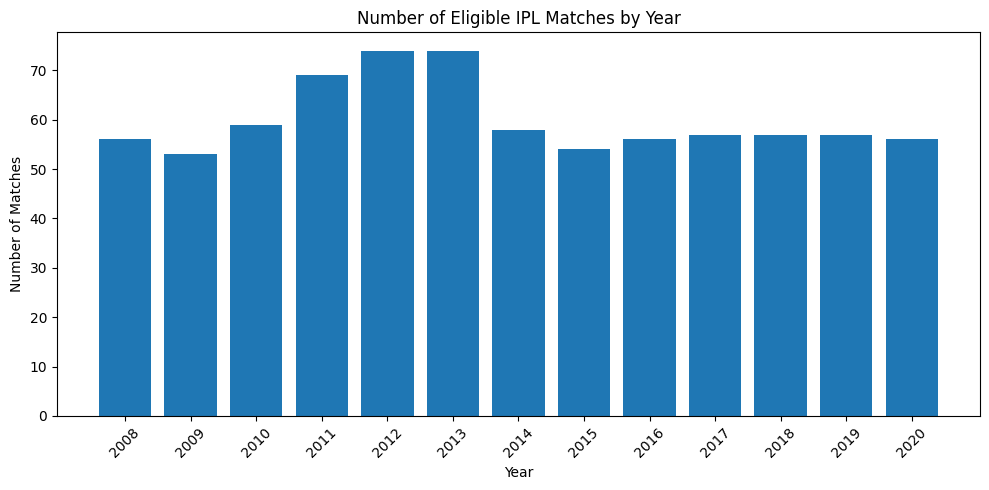

In [ ]:
matches_per_year = (
    matches_clean["year"]
    .value_counts()
    .sort_index()
)

print(matches_per_year)

plt.figure(figsize=(10, 5))

plt.bar(
    matches_per_year.index.astype(str),
    matches_per_year.values
)

plt.xlabel("Year")
plt.ylabel("Number of Matches")

plt.title(
    "Number of Eligible IPL Matches by Year"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 22. Target-Class Distribution

The distribution of chasing wins and chasing losses is examined.

A highly imbalanced target could require special treatment during model evaluation or training.

In this dataset, however, the two classes are reasonably balanced.
### Observation

The chasing team won approximately 54.7% of the eligible matches, while the defending team won approximately 45.3%.

The target distribution is therefore reasonably balanced, so techniques such as oversampling or SMOTE are not required at this stage.

Counts:
chasing_team_won
0    353
1    427
Name: count, dtype: int64

Percentages:
chasing_team_won
0    45.25641
1    54.74359
Name: proportion, dtype: float64


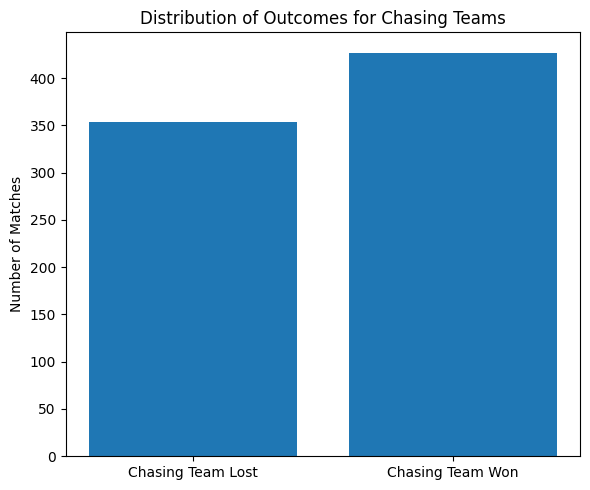

In [ ]:
target_counts = (
    matches_clean["chasing_team_won"]
    .value_counts()
    .sort_index()
)

target_percentages = (
    matches_clean["chasing_team_won"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Counts:")
print(target_counts)

print("\nPercentages:")
print(target_percentages)

plt.figure(figsize=(6, 5))

plt.bar(
    [
        "Chasing Team Lost",
        "Chasing Team Won"
    ],
    [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ]
)

plt.ylabel("Number of Matches")

plt.title(
    "Distribution of Outcomes for Chasing Teams"
)

plt.tight_layout()
plt.show()

## 23. Distribution of Chase Targets

The target score represents the number of runs required by the second-innings team to win.

Its distribution is examined because target size is expected to influence the difficulty of a chase.

count    780.000000
mean     163.478205
std       29.869477
min       68.000000
25%      144.000000
50%      164.000000
75%      183.000000
max      264.000000
Name: target_runs, dtype: float64


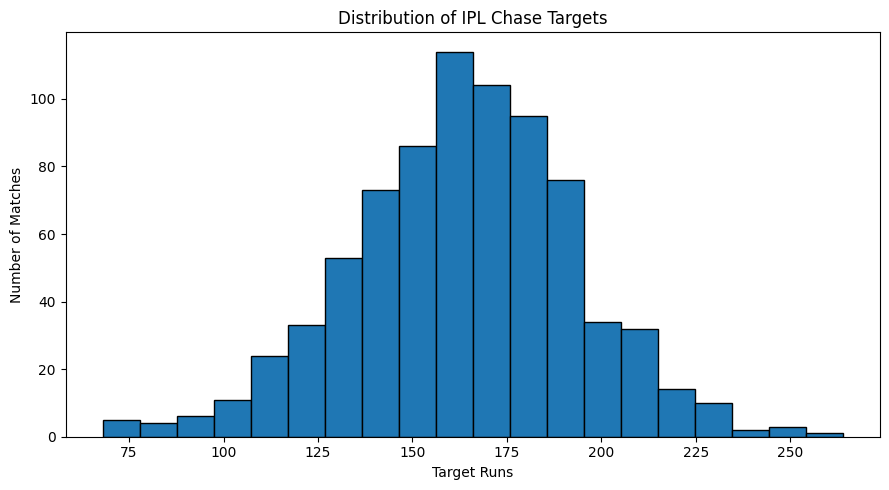

In [ ]:
print(
    matches_clean["target_runs"]
    .describe()
)

plt.figure(figsize=(9, 5))

plt.hist(
    matches_clean["target_runs"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Target Runs")
plt.ylabel("Number of Matches")

plt.title(
    "Distribution of IPL Chase Targets"
)

plt.tight_layout()
plt.show()

### Observation

IPL chase targets vary substantially across matches.

**This indicates that the target itself may provide important predictive information because chasing a relatively small total is fundamentally different from chasing a very large total.**

## 24. Relationship Between Target Size and Chase Success

The target score is divided into interpretable ranges and the historical success rate of chasing teams is calculated for each range.

This analysis helps determine whether target size contains meaningful predictive information.

In [ ]:
target_bins = [
    0,
    139,
    159,
    179,
    199,
    float("inf")
]

target_labels = [
    "<140",
    "140-159",
    "160-179",
    "180-199",
    "200+"
]

matches_clean["target_band"] = pd.cut(
    matches_clean["target_runs"],
    bins=target_bins,
    labels=target_labels
)

target_analysis = (
    matches_clean
    .groupby(
        "target_band",
        observed=False
    )["chasing_team_won"]
    .agg(
        number_of_matches="count",
        chasing_win_rate="mean"
    )
)

target_analysis["chasing_win_rate"] *= 100

print(target_analysis)

             number_of_matches  chasing_win_rate
target_band                                     
<140                       155         80.000000
140-159                    172         70.348837
160-179                    230         50.000000
180-199                    146         37.671233
200+                        77         15.584416


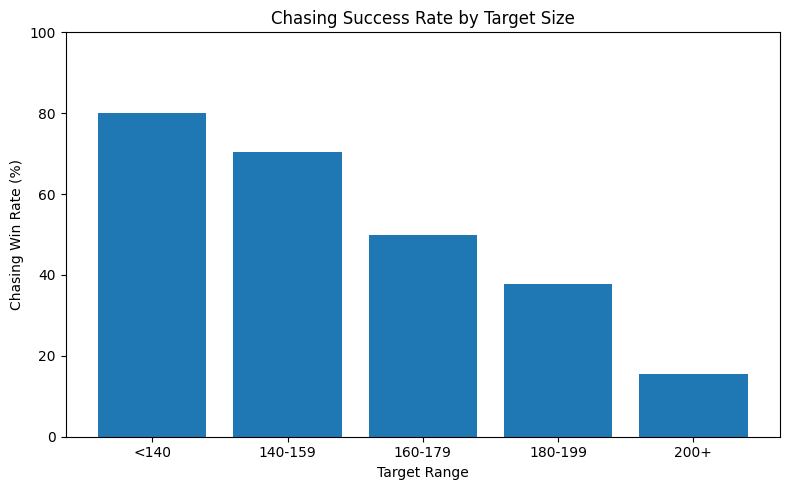

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    target_analysis.index.astype(str),
    target_analysis["chasing_win_rate"]
)

plt.xlabel("Target Range")
plt.ylabel("Chasing Win Rate (%)")

plt.title(
    "Chasing Success Rate by Target Size"
)

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### Observation

A clear relationship exists between target size and the historical probability of a successful chase.

Smaller targets are chased successfully much more frequently, while targets above 200 have a substantially lower success rate.

This provides evidence that `target_runs` should be considered an important input feature for the win-probability model.

## 25. Team-Wise Chasing Performance

Historical chasing performance is calculated for each franchise.

The analysis includes both the number of chases and the percentage of successful chases because percentages based on very small numbers of matches can be misleading.

In [ ]:
team_chase_stats = (
    matches_clean
    .groupby("chasing_team")
    ["chasing_team_won"]
    .agg(
        number_of_chases="count",
        chasing_wins="sum",
        chasing_win_rate="mean"
    )
)

team_chase_stats["chasing_win_rate"] *= 100

team_chase_stats = (
    team_chase_stats
    .sort_values(
        "chasing_win_rate",
        ascending=False
    )
)

print(team_chase_stats)

                             number_of_chases  chasing_wins  chasing_win_rate
chasing_team                                                                 
Gujarat Lions                              16            12         75.000000
Chennai Super Kings                        83            53         63.855422
Mumbai Indians                             91            56         61.538462
Rising Pune Supergiant                     13             8         61.538462
Kolkata Knight Riders                      92            55         59.782609
Sunrisers Hyderabad                        51            30         58.823529
Rajasthan Royals                           87            51         58.620690
Kings XI Punjab                            86            44         51.162791
Royal Challengers Bangalore                96            49         51.041667
Kochi Tuskers Kerala                        6             3         50.000000
Delhi Capitals                            102            49     

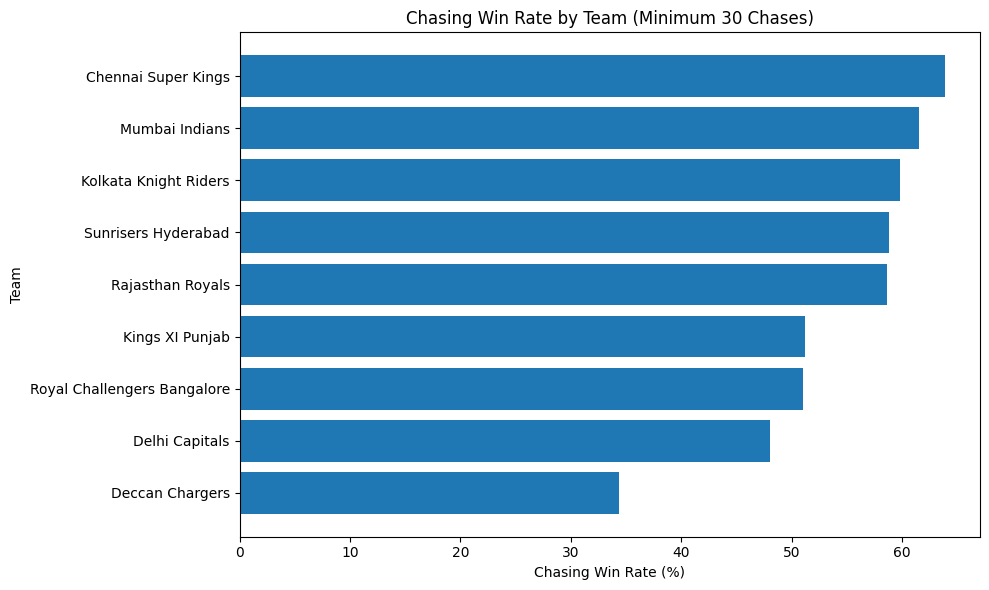

In [ ]:
team_plot = team_chase_stats[
    team_chase_stats["number_of_chases"]
    >= 30
].sort_values(
    "chasing_win_rate"
)

plt.figure(figsize=(10, 6))

plt.barh(
    team_plot.index,
    team_plot["chasing_win_rate"]
)

plt.xlabel("Chasing Win Rate (%)")
plt.ylabel("Team")

plt.title(
    "Chasing Win Rate by Team "
    "(Minimum 30 Chases)"
)

plt.tight_layout()
plt.show()

### Observation

Different franchises show different historical chasing success rates.

**This suggests that team identity may contain useful predictive information.**

**However, performance percentages for franchises with very few historical chases should be interpreted cautiously because their estimates are based on small sample sizes.**

## 26. Inspect Venue Categories

**Venue is a potential categorical feature because different grounds can have different scoring conditions.**

Before analysing venue-level performance, the unique venue strings are inspected to identify inconsistent names and historical aliases.

In [ ]:
print(
    "Number of unique venue strings:",
    matches_clean["venue"].nunique()
)

print("\nVENUES:\n")

for venue in sorted(
    matches_clean["venue"]
    .dropna()
    .unique()
):
    print(venue)

Number of unique venue strings: 41

VENUES:

Arun Jaitley Stadium
Barabati Stadium
Brabourne Stadium
Brabourne Stadium, Mumbai
Buffalo Park
De Beers Diamond Oval
Dr DY Patil Sports Academy
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium
Dubai International Cricket Stadium
Eden Gardens
Feroz Shah Kotla
Green Park
Himachal Pradesh Cricket Association Stadium
Holkar Cricket Stadium
JSCA International Stadium Complex
Kingsmead
M Chinnaswamy Stadium
M.Chinnaswamy Stadium
MA Chidambaram Stadium
MA Chidambaram Stadium, Chepauk
Maharashtra Cricket Association Stadium
Nehru Stadium
New Wanderers Stadium
Newlands
OUTsurance Oval
Punjab Cricket Association IS Bindra Stadium
Punjab Cricket Association IS Bindra Stadium, Mohali
Punjab Cricket Association Stadium, Mohali
Rajiv Gandhi International Stadium
Rajiv Gandhi International Stadium, Uppal
Sardar Patel Stadium, Motera
Saurashtra Cricket Association Stadium
Sawai Mansingh Stadium
Shaheed Veer Narayan Singh International Stadium
Sharjah Cri

### Observation

The venue inspection reveals that some stadiums appear under multiple names or slightly different spellings.

Examples include:

- `M Chinnaswamy Stadium` and `M.Chinnaswamy Stadium`
- `MA Chidambaram Stadium` and `MA Chidambaram Stadium, Chepauk`
- `Rajiv Gandhi International Stadium` and `Rajiv Gandhi International Stadium, Uppal`
- `Feroz Shah Kotla` and `Arun Jaitley Stadium`

These aliases should be standardized before venue is used as a categorical model feature.

Venue normalization will therefore be performed before continuing with delivery-level exploratory data analysis.

In [ ]:
VENUE_NAME_MAP = {
    "M.Chinnaswamy Stadium":
        "M Chinnaswamy Stadium",

    "MA Chidambaram Stadium, Chepauk":
        "MA Chidambaram Stadium",

    "Rajiv Gandhi International Stadium, Uppal":
        "Rajiv Gandhi International Stadium",

    "Feroz Shah Kotla":
        "Arun Jaitley Stadium",

    "Punjab Cricket Association Stadium, Mohali":
        "Punjab Cricket Association IS Bindra Stadium, Mohali",

    "Punjab Cricket Association IS Bindra Stadium":
        "Punjab Cricket Association IS Bindra Stadium, Mohali",

    "Brabourne Stadium, Mumbai":
        "Brabourne Stadium"
}

print(
    "Unique venues before normalization:",
    matches_clean["venue"].nunique()
)

matches_clean["venue"] = (
    matches_clean["venue"]
    .replace(VENUE_NAME_MAP)
)

print(
    "Unique venues after normalization:",
    matches_clean["venue"].nunique()
)

Unique venues before normalization: 41
Unique venues after normalization: 34


### Observation

Venue normalization reduces the number of unique venue labels from 41 to 34.

This does not remove any matches. It only combines different names referring to the same stadium.

This reduces unnecessary categorical fragmentation before modelling.

## 28. Venue-Wise Chasing Performance

The historical chasing success rate is calculated for each normalized venue.

Only venues with at least 15 eligible matches are plotted so that conclusions are not dominated by very small sample sizes.

In [ ]:
venue_chase_stats = (
    matches_clean
    .groupby("venue")["chasing_team_won"]
    .agg(
        number_of_chases="count",
        chasing_wins="sum",
        chasing_win_rate="mean"
    )
)

venue_chase_stats["chasing_win_rate"] *= 100

venue_chase_stats = (
    venue_chase_stats
    .sort_values(
        "chasing_win_rate",
        ascending=False
    )
)

print(venue_chase_stats)

                                                    number_of_chases  \
venue                                                                  
Green Park                                                         4   
Holkar Cricket Stadium                                             9   
SuperSport Park                                                   11   
JSCA International Stadium Complex                                 7   
Sawai Mansingh Stadium                                            46   
Shaheed Veer Narayan Singh International Stadium                   6   
Saurashtra Cricket Association Stadium                             9   
De Beers Diamond Oval                                              3   
Maharashtra Cricket Association Stadium                           22   
New Wanderers Stadium                                              8   
Sharjah Cricket Stadium                                           18   
Sheikh Zayed Stadium                                            

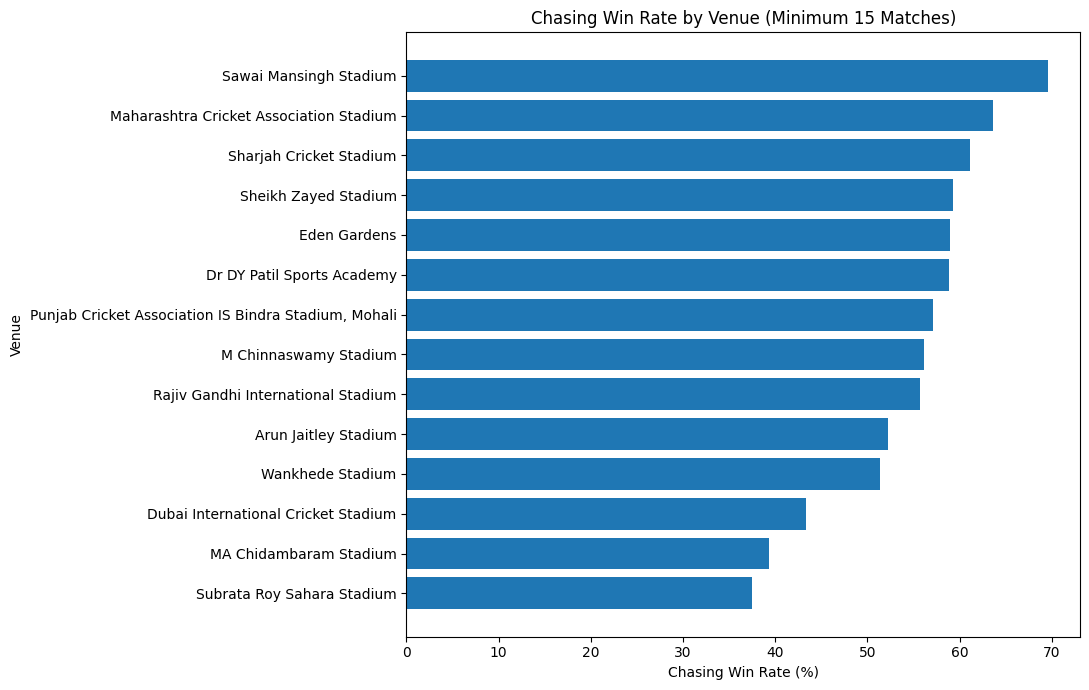

In [ ]:
venue_plot = venue_chase_stats[
    venue_chase_stats["number_of_chases"] >= 15
].sort_values(
    "chasing_win_rate"
)

plt.figure(figsize=(11, 7))

plt.barh(
    venue_plot.index,
    venue_plot["chasing_win_rate"]
)

plt.xlabel("Chasing Win Rate (%)")
plt.ylabel("Venue")

plt.title(
    "Chasing Win Rate by Venue "
    "(Minimum 15 Matches)"
)

plt.tight_layout()
plt.show()

### Observation

Chasing success varies across venues.

This suggests that venue may provide useful predictive information because different grounds can have different scoring and chasing conditions.

However, these percentages should not be interpreted as causal effects because team strength, seasons and match conditions also differ across venues.

Venue will therefore be retained as a candidate categorical feature.

# Delivery-Level Exploratory Data Analysis

The match-level analysis describes overall outcomes, targets, teams and venues.

The next stage examines second-innings ball-by-ball data because the final predictor will make predictions from live chase states.

The analysis focuses on:

- Legal and illegal deliveries
- Extras
- Dismissal types
- Scoring patterns across overs
- Wicket patterns across overs
- Powerplay, middle-over and death-over behaviour
- Data-quality issues that affect the construction of live match-state features

## 30. Distribution of Extras

Not every recorded delivery consumes one legal ball.

In cricket:

- A wide does not consume a legal delivery.
- A no-ball does not consume a legal delivery.
- Byes and leg-byes normally occur on legal deliveries.

**This distinction is important because the future `balls_remaining` feature must be based on legal balls rather than simply counting dataset rows.**

In [ ]:
extras_distribution = (
    second_innings["extras_type"]
    .value_counts(dropna=False)
)

print(extras_distribution)

extras_type
NaN        85753
wides       2782
legbyes     1406
noballs      328
byes         205
penalty        2
Name: count, dtype: int64


## 31. Identify Legal Deliveries

A delivery is considered illegal for ball-counting purposes when it is recorded as either:

- `wides`
- `noballs`

All other recorded delivery types are treated as legal deliveries.

In [ ]:
second_innings["is_legal_ball"] = (
    ~second_innings["extras_type"]
    .isin(["wides", "noballs"])
)

print(
    "Total delivery records:",
    len(second_innings)
)

print(
    "Legal deliveries:",
    second_innings["is_legal_ball"].sum()
)

print(
    "Illegal deliveries:",
    (~second_innings["is_legal_ball"]).sum()
)

Total delivery records: 90476
Legal deliveries: 87366
Illegal deliveries: 3110


### Observation

The second-innings dataset contains 90,476 recorded delivery events, but only 87,366 of them consume legal balls.

Therefore, the raw number of rows cannot be used directly to calculate balls bowled or balls remaining.

Wides and no-balls must be handled explicitly.

## 32. Inspect Dismissal Types

The dataset contains several types of dismissals.

Not every value recorded in `is_wicket` should automatically reduce the number of wickets remaining.

For example, `retired hurt` does not represent a conventional wicket lost by the batting side.

Therefore, dismissal types are inspected before constructing the wicket-state feature.

## 33. Define Wickets Lost

For the purpose of describing the batting team's match state, `retired hurt` is not treated as a wicket lost.

Other recorded dismissals that remove a batter are counted as wickets lost.

In [ ]:
second_innings["wicket_lost"] = (
    (
        second_innings["is_wicket"] == 1
    )
    &
    (
        second_innings["dismissal_kind"]
        != "retired hurt"
    )
).astype(int)

print(
    "Raw is_wicket count:",
    second_innings["is_wicket"].sum()
)

print(
    "Wickets counted for match state:",
    second_innings["wicket_lost"].sum()
)

Raw is_wicket count: 4410
Wickets counted for match state: 4404


## 34. Scoring Rate Across Overs

The scoring pattern across the second innings is examined.

For each over number:

1. Total runs are aggregated.
2. Only legal balls are counted in the denominator.
3. The equivalent run rate is calculated.

The dataset uses zero-based over numbering, so `over = 0` represents the first over.

In [ ]:
over_stats = (
    second_innings
    .groupby("over")
    .agg(
        runs=("total_runs", "sum"),
        legal_balls=("is_legal_ball", "sum"),
        wickets=("wicket_lost", "sum")
    )
)

over_stats["run_rate"] = (
    over_stats["runs"]
    / over_stats["legal_balls"]
    * 6
)

over_stats["wickets_per_100_legal_balls"] = (
    over_stats["wickets"]
    / over_stats["legal_balls"]
    * 100
)

over_stats["display_over"] = (
    over_stats.index + 1
)

display(over_stats)

,runs,legal_balls,wickets,run_rate,wickets_per_100_legal_balls,display_over
over,,,,,,
0,4824,4680,166,6.184615,3.547009,1
1,5723,4680,199,7.337179,4.252137,2
2,6279,4680,198,8.050000,4.230769,3
3,6673,4680,185,8.555128,3.952991,4
4,6325,4682,212,8.105510,4.527979,5
5,6493,4677,181,8.329699,3.870002,6
6,5302,4674,161,6.806162,3.444587,7
7,5550,4669,187,7.132148,4.005140,8
8,5894,4651,170,7.603526,3.655128,9


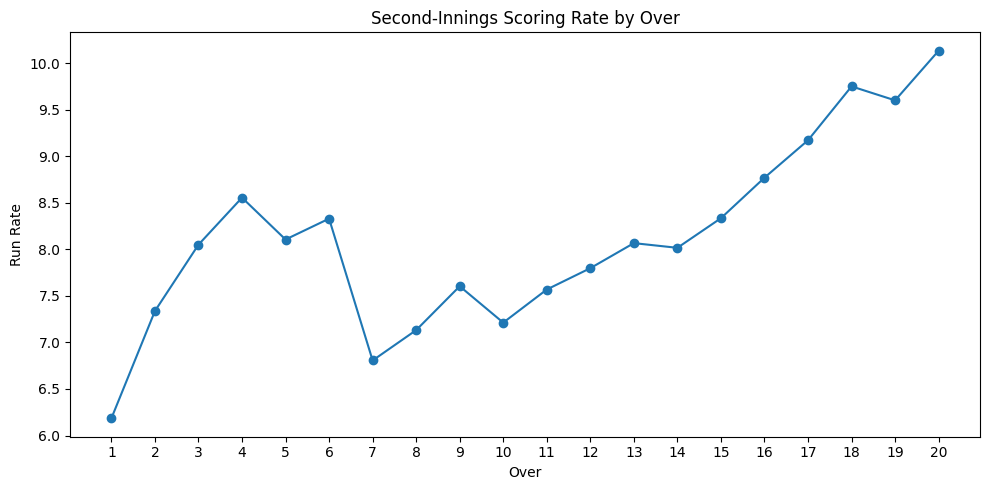

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    over_stats["display_over"],
    over_stats["run_rate"],
    marker="o"
)

plt.xlabel("Over")
plt.ylabel("Run Rate")

plt.title(
    "Second-Innings Scoring Rate by Over"
)

plt.xticks(
    range(1, 21)
)

plt.tight_layout()
plt.show()

### Observation

The scoring rate is not constant throughout a chase.

Scoring generally increases towards the later overs as batting teams attempt to reach the target with fewer deliveries remaining.

This supports the importance of time-dependent match-state variables such as:

- Balls remaining
- Current run rate
- Required run rate
- Recent scoring rate

## 35. Wicket Frequency Across Overs

The frequency of wickets is examined across the innings.

Because different overs contain different numbers of observations, wickets are expressed relative to the number of legal balls rather than using raw wicket counts alone.

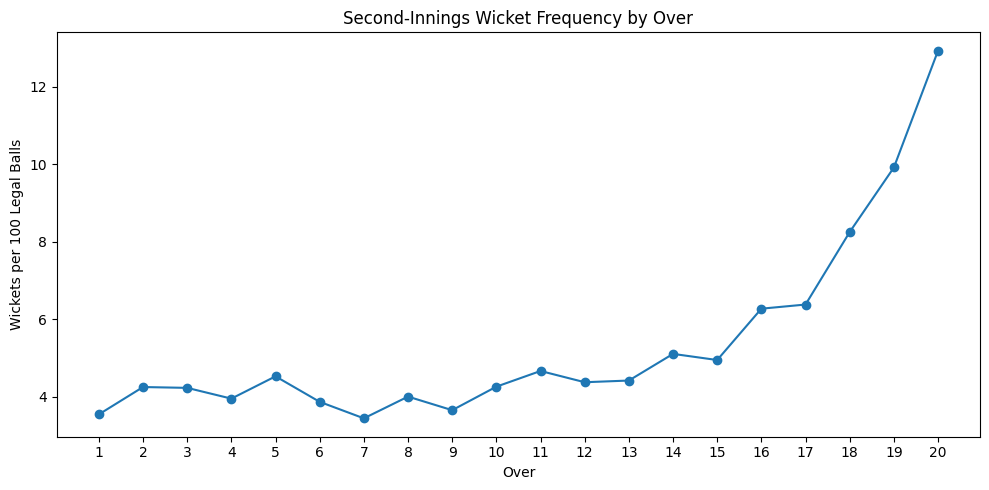

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    over_stats["display_over"],
    over_stats[
        "wickets_per_100_legal_balls"
    ],
    marker="o"
)

plt.xlabel("Over")

plt.ylabel(
    "Wickets per 100 Legal Balls"
)

plt.title(
    "Second-Innings Wicket Frequency by Over"
)

plt.xticks(
    range(1, 21)
)

plt.tight_layout()
plt.show()

### Observation

Wicket frequency increases substantially in the later stages of the innings.

This is consistent with teams taking greater batting risks when the number of remaining deliveries becomes small.

Therefore, the number of wickets remaining is likely to be an important component of the live match state.

## 36. Divide the Innings into Cricket Phases

For easier interpretation, each second innings is divided into three commonly used phases:

- Powerplay: Overs 1–6
- Middle Overs: Overs 7–15
- Death Overs: Overs 16–20

Scoring and wicket rates are compared across these phases.

In [ ]:
second_innings["phase"] = pd.cut(
    second_innings["over"],
    bins=[-1, 5, 14, 19],
    labels=[
        "Powerplay (Overs 1-6)",
        "Middle (Overs 7-15)",
        "Death (Overs 16-20)"
    ]
)

phase_stats = (
    second_innings
    .groupby(
        "phase",
        observed=False
    )
    .agg(
        runs=("total_runs", "sum"),
        legal_balls=("is_legal_ball", "sum"),
        wickets=("wicket_lost", "sum")
    )
)

phase_stats["run_rate"] = (
    phase_stats["runs"]
    / phase_stats["legal_balls"]
    * 6
)

phase_stats[
    "wickets_per_100_legal_balls"
] = (
    phase_stats["wickets"]
    / phase_stats["legal_balls"]
    * 100
)

display(phase_stats)

,runs,legal_balls,wickets,run_rate,wickets_per_100_legal_balls
phase,,,,,
Powerplay (Overs 1-6),36317,28079,1141,7.760319,4.063535
Middle (Overs 7-15),52506,41406,1786,7.608463,4.313385
Death (Overs 16-20),28026,17881,1477,9.404172,8.260164


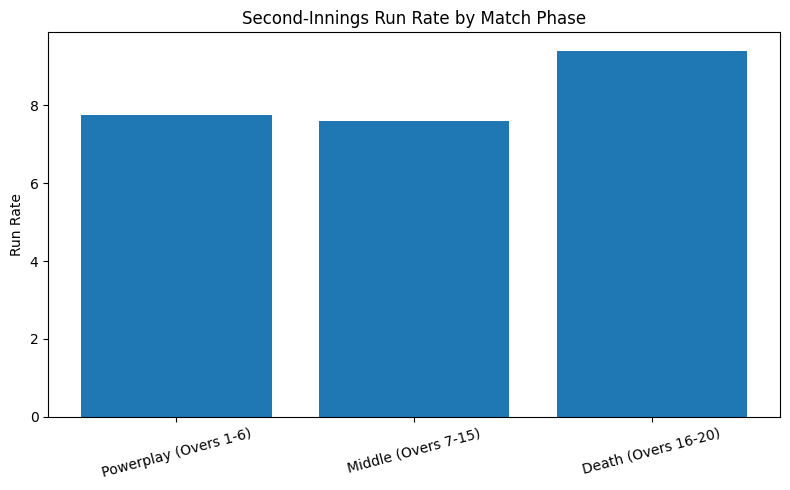

In [ ]:
phase_plot = (
    phase_stats[
        ["run_rate"]
    ]
)

plt.figure(figsize=(8, 5))

plt.bar(
    phase_plot.index.astype(str),
    phase_plot["run_rate"]
)

plt.ylabel("Run Rate")

plt.title(
    "Second-Innings Run Rate by Match Phase"
)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Observation

The death overs have the highest scoring rate, with approximately 9.4 runs per over compared with around 7.6–7.8 during the earlier phases.

The death overs also contain a substantially higher wicket frequency.

This shows that the statistical behaviour of a chase changes as the innings progresses.

In [ ]:
##in one match alone,there were 7 legal deliveries,we are normalizing it as well

second_innings[
    (
        second_innings["match_id"]
        == 1216497
    )
    &
    (
        second_innings["over"]
        == 4
    )
][
    [
        "over",
        "ball",
        "batsman_runs",
        "extra_runs",
        "total_runs",
        "extras_type",
        "is_legal_ball"
    ]
]

,over,ball,batsman_runs,extra_runs,total_runs,extras_type,is_legal_ball
180391,4,1,0,0,0,NaN,True
180392,4,2,6,0,6,NaN,True
180393,4,3,0,0,0,NaN,True
180394,4,4,0,0,0,NaN,True
180395,4,5,0,1,1,noballs,False
180396,4,6,0,2,2,legbyes,True
180397,4,7,1,0,1,NaN,True
180398,4,8,0,1,1,wides,False
180399,4,9,1,0,1,NaN,True


## Delivery-Level EDA Summary

The delivery-level analysis produced several important findings:

1. The cleaned second-innings data contains 90,476 recorded delivery events across 780 matches.

2. Only 87,366 records represent legal deliveries because wides and no-balls do not consume a legal ball.

3. Wicket calculations must treat retired-hurt events separately.

4. Scoring rate changes substantially across the innings and is highest during the death overs.

5. Wicket frequency also increases during the later overs.

6. Ball position, current scoring rate and wickets remaining therefore contain meaningful information about the state of a chase.

7. A rare source irregularity involving more than six legal deliveries in an over was detected and will be handled robustly during feature engineering.

# Feature Engineering

The cleaned second-innings delivery data will now be converted into live match-state observations.

Each row will represent the state of a chase immediately after a delivery.

The engineered variables will describe:

- Match context
- Current score
- Runs still required
- Legal balls remaining
- Wickets remaining
- Current run rate
- Required run rate

The final match outcome will be attached to every state as the classification target.

## 38. Merge Match-Level Information with Delivery Data

The delivery dataset contains the evolving ball-by-ball state, while the match dataset contains static information such as:

- Venue
- Target runs
- Target overs
- Match date
- Year
- Final chase outcome

These match-level variables are merged with every second-innings delivery using `match_id`.

In [ ]:
match_metadata = (
    matches_clean[
        [
            "id",
            "date",
            "year",
            "venue",
            "target_runs",
            "target_overs",
            "chasing_team_won"
        ]
    ]
    .rename(
        columns={"id": "match_id"}
    )
)

state_data = second_innings.merge(
    match_metadata,
    on="match_id",
    how="left",
    validate="many_to_one"
)

state_data = (
    state_data
    .sort_values(
        ["match_id", "over", "ball"]
    )
    .reset_index(drop=True)
)

print(
    "State-data shape:",
    state_data.shape
)

State-data shape: (90476, 26)


## 39. Calculate the Current Score

The live score after each delivery is calculated by cumulatively summing `total_runs` within each match.

`total_runs` is used because it includes both batter runs and extras.

In [ ]:
state_data["current_score"] = (
    state_data
    .groupby("match_id")["total_runs"]
    .cumsum()
)

display(
    state_data[
        [
            "match_id",
            "over",
            "ball",
            "total_runs",
            "current_score"
        ]
    ].head(15)
)

,match_id,over,ball,total_runs,current_score
0,335982,0,1,1,1
1,335982,0,2,1,2
2,335982,0,3,0,2
3,335982,0,4,1,3
4,335982,0,5,1,4
5,335982,0,6,0,4
6,335982,0,7,0,4
7,335982,1,1,0,4
8,335982,1,2,0,4
9,335982,1,3,4,8


## 40. Calculate Wickets Lost and Wickets Remaining

The previously constructed `wicket_lost` variable is cumulatively summed within each match.

The number of wickets remaining is then calculated as:

`wickets_remaining = 10 - wickets_lost`

Retired-hurt events are not treated as conventional wickets.

In [ ]:
state_data["wickets_lost"] = (
    state_data
    .groupby("match_id")["wicket_lost"]
    .cumsum()
)

state_data["wickets_remaining"] = (
    10 - state_data["wickets_lost"]
).clip(lower=0)

display(
    state_data[
        [
            "match_id",
            "over",
            "ball",
            "wicket_lost",
            "wickets_lost",
            "wickets_remaining"
        ]
    ].head(15)
)

,match_id,over,ball,wicket_lost,wickets_lost,wickets_remaining
0,335982,0,1,0,0,10
1,335982,0,2,0,0,10
2,335982,0,3,0,0,10
3,335982,0,4,0,0,10
4,335982,0,5,0,0,10
5,335982,0,6,0,0,10
6,335982,0,7,0,0,10
7,335982,1,1,1,1,9
8,335982,1,2,0,1,9
9,335982,1,3,0,1,9


## 41. Determine the Number of Scheduled Balls

Most IPL innings contain 20 overs, but the cleaned dataset also contains a small number of valid shortened matches.

Therefore, the total number of scheduled legal deliveries is calculated using:

`scheduled_balls = target_overs × 6`

instead of assuming that every innings contains 120 balls.

In [ ]:
state_data["scheduled_balls"] = (
    state_data["target_overs"] * 6
).round().astype(int)

print(
    state_data[
        [
            "target_overs",
            "scheduled_balls"
        ]
    ]
    .drop_duplicates()
    .sort_values("target_overs")
)


       target_overs  scheduled_balls
43961           8.0               48
54769          10.0               60
27454          12.0               72
3173           16.0               96
46786          17.0              102
3373           18.0              108
0              20.0              120


## 42. Calculate Legal Balls Bowled

Wides and no-balls do not consume a legal delivery.

Therefore, the number of balls bowled cannot be obtained by simply counting delivery rows.

The number of legal balls within each over is calculated cumulatively.

A rare source-data irregularity contains seven recorded legal deliveries in one over, so the within-over count is capped at six for the purpose of calculating official match position.

In [ ]:
state_data["legal_ball_in_over"] = (
    state_data
    .groupby(
        ["match_id", "over"]
    )["is_legal_ball"]
    .cumsum()
)

state_data[
    "legal_ball_in_over_capped"
] = (
    state_data["legal_ball_in_over"]
    .clip(upper=6)
)

state_data["legal_balls_bowled"] = (
    state_data["over"] * 6
    +
    state_data[
        "legal_ball_in_over_capped"
    ]
).astype(int)

## 43. Calculate Balls Remaining

The number of legal balls remaining is calculated as:

`balls_remaining = scheduled_balls - legal_balls_bowled`

The value is restricted to a minimum of zero to protect against source-data irregularities.

In [ ]:
state_data["balls_remaining"] = (
    state_data["scheduled_balls"]
    -
    state_data["legal_balls_bowled"]
).clip(lower=0)

display(
    state_data[
        [
            "match_id",
            "over",
            "ball",
            "is_legal_ball",
            "legal_balls_bowled",
            "balls_remaining"
        ]
    ].head(20)
)

,match_id,over,ball,is_legal_ball,legal_balls_bowled,balls_remaining
0,335982,0,1,True,1,119
1,335982,0,2,False,1,119
2,335982,0,3,True,2,118
3,335982,0,4,True,3,117
4,335982,0,5,True,4,116
5,335982,0,6,True,5,115
6,335982,0,7,True,6,114
7,335982,1,1,True,7,113
8,335982,1,2,True,8,112
9,335982,1,3,True,9,111


## 44. Calculate Runs Required

At every point in the chase:

`runs_required = target_runs - current_score`

If the chasing team exceeds the target after the final scoring shot, the value is restricted to zero.

In [ ]:
state_data["runs_required"] = (
    state_data["target_runs"]
    -
    state_data["current_score"]
).clip(lower=0)

display(
    state_data[
        [
            "target_runs",
            "current_score",
            "runs_required"
        ]
    ].head(15)
)

,target_runs,current_score,runs_required
0,223.0,1,222.0
1,223.0,2,221.0
2,223.0,2,221.0
3,223.0,3,220.0
4,223.0,4,219.0
5,223.0,4,219.0
6,223.0,4,219.0
7,223.0,4,219.0
8,223.0,4,219.0
9,223.0,8,215.0


## 45. Calculate Current Run Rate

Current run rate measures how quickly the chasing team has scored so far.

It is calculated using legal deliveries:

`current_run_rate = current_score × 6 / legal_balls_bowled`

If no legal delivery has yet been bowled, current run rate is undefined. These very early states will later be excluded from the modelling dataset.

In [ ]:
state_data["current_run_rate"] = np.where(
    state_data["legal_balls_bowled"] > 0,

    (
        state_data["current_score"]
        * 6
        / state_data["legal_balls_bowled"]
    ),

    np.nan
)

print(
    "States before the first legal ball:",
    state_data[
        "current_run_rate"
    ].isna().sum()
)

States before the first legal ball: 63


## 46. Calculate Required Run Rate

Required run rate measures the scoring rate necessary from the remaining deliveries.

It is calculated as:

`required_run_rate = runs_required × 6 / balls_remaining`

This variable captures the pressure of the chase more directly than target score alone.

In [ ]:
state_data["required_run_rate"] = np.where(
    state_data["balls_remaining"] > 0,

    (
        state_data["runs_required"]
        * 6
        / state_data["balls_remaining"]
    ),

    np.where(
        state_data["runs_required"] == 0,
        0,
        np.nan
    )
)

## 47. Remove the Final Delivery of Each Match

The final delivery of a match is not useful for evaluating predictive performance because the match result is already determined at that point.

For example:

- If the target has been reached, the chase has already been won.
- If the final legal delivery has been bowled without reaching the target, the chase has already been lost.
- If the batting side has been dismissed, the result is already known.

Including these states could artificially increase model accuracy.

Therefore, the final recorded delivery from each match is excluded from model training and evaluation.

In [ ]:
state_data["is_last_delivery"] = (
    state_data
    .groupby("match_id")
    .cumcount(ascending=False)
    .eq(0)
)

print(
    "Final-delivery rows:",
    state_data[
        "is_last_delivery"
    ].sum()
)

Final-delivery rows: 780


## 48. Remove States Before the First Legal Delivery

A small number of innings begin with a wide or no-ball.

Before the first legal delivery, current run rate is mathematically undefined.

Only 63 such rows exist in the complete dataset, so these states are excluded from the modelling table rather than assigning an artificial run-rate value.

In [ ]:
model_states = state_data[
    (~state_data["is_last_delivery"])
    &
    (state_data["legal_balls_bowled"] > 0)
].copy()

print(
    "Original second-innings states:",
    len(state_data)
)

print(
    "Final modelling states:",
    len(model_states)
)

Original second-innings states: 90476
Final modelling states: 89633


## 49. Check the Engineered Features for Missing Values

Before defining the model inputs, the engineered variables are checked for missing values.

The modelling dataset should contain complete values for all core predictive variables.

In [ ]:
engineered_columns = [
    "batting_team",
    "bowling_team",
    "venue",
    "target_runs",
    "current_score",
    "runs_required",
    "balls_remaining",
    "wickets_remaining",
    "current_run_rate",
    "required_run_rate",
    "chasing_team_won"
]

print(
    model_states[
        engineered_columns
    ]
    .isna()
    .sum()
)

batting_team         0
bowling_team         0
venue                0
target_runs          0
current_score        0
runs_required        0
balls_remaining      0
wickets_remaining    0
current_run_rate     0
required_run_rate    0
chasing_team_won     0
dtype: int64


## 50. Inspect the Final Live Match-State Table

Each row now represents one real-time second-innings match state.

The match ID, date and year are retained for chronological splitting and validation, but they will not be used directly as predictive features.

In [ ]:
display_columns = [
    "match_id",
    "date",
    "year",
    "batting_team",
    "bowling_team",
    "venue",
    "target_runs",
    "current_score",
    "runs_required",
    "balls_remaining",
    "wickets_remaining",
    "current_run_rate",
    "required_run_rate",
    "chasing_team_won"
]

display(
    model_states[
        display_columns
    ].head(20)
)

,match_id,date,year,batting_team,bowling_team,venue,target_runs,current_score,runs_required,balls_remaining,wickets_remaining,current_run_rate,required_run_rate,chasing_team_won
0,335982,2008-04-18,2008,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,223.0,1,222.0,119,10,6.000000,11.193277,0
1,335982,2008-04-18,2008,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,223.0,2,221.0,119,10,12.000000,11.142857,0
2,335982,2008-04-18,2008,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,223.0,2,221.0,118,10,6.000000,11.237288,0
3,335982,2008-04-18,2008,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,223.0,3,220.0,117,10,6.000000,11.282051,0
4,335982,2008-04-18,2008,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,223.0,4,219.0,116,10,6.000000,11.327586,0
5,335982,2008-04-18,2008,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,223.0,4,219.0,115,10,4.800000,11.426087,0
6,335982,2008-04-18,2008,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,223.0,4,219.0,114,10,4.000000,11.526316,0
7,335982,2008-04-18,2008,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,223.0,4,219.0,113,9,3.428571,11.628319,0
8,335982,2008-04-18,2008,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,223.0,4,219.0,112,9,3.000000,11.732143,0
9,335982,2008-04-18,2008,Royal Challengers Bangalore,Kolkata Knight Riders,M Chinnaswamy Stadium,223.0,8,215.0,111,9,5.333333,11.621622,0


## 51. Define the Core Feature Set

The following variables will form the initial model feature set.

### Categorical Features

- `batting_team`
- `bowling_team`
- `venue`

### Numerical Features

- `target_runs`
- `runs_required`
- `balls_remaining`
- `wickets_remaining`
- `current_run_rate`
- `required_run_rate`

`current_score` is retained in the dataset for interpretation but is not included in the initial model feature set because:

`current_score = target_runs - runs_required`

Including all three would introduce exact redundancy.

The match ID, date and year are retained only for chronological splitting and will not be model inputs.

In [ ]:
categorical_features = [
    "batting_team",
    "bowling_team",
    "venue"
]

numerical_features = [
    "target_runs",
    "runs_required",
    "balls_remaining",
    "wickets_remaining",
    "current_run_rate",
    "required_run_rate"
]

model_features = (
    categorical_features
    + numerical_features
)

target_column = "chasing_team_won"

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nTarget:")
print(target_column)

Categorical features:
['batting_team', 'bowling_team', 'venue']

Numerical features:
['target_runs', 'runs_required', 'balls_remaining', 'wickets_remaining', 'current_run_rate', 'required_run_rate']

Target:
chasing_team_won


In [ ]:
## 52. Verify the Number of Modelling States by Year

##The number of matches and delivery-level states available in each year is examined before constructing the chronological validation folds.

In [ ]:
states_by_year = (
    model_states
    .groupby("year")
    .agg(
        matches=("match_id", "nunique"),
        states=("match_id", "size")
    )
)

display(states_by_year)

,matches,states
year,,
2008,56,6260
2009,53,6181
2010,59,6810
2011,69,7840
2012,74,8593
2013,74,8508
2014,58,6696
2015,54,6186
2016,56,6394


## Feature Engineering Summary

The raw second-innings delivery data has now been converted into a structured live match-state dataset.

For every predictive state, the model has information about:

- Teams
- Venue
- Target
- Runs still required
- Balls remaining
- Wickets remaining
- Current run rate
- Required run rate

The cleaned modelling dataset contains approximately 89,633 live chase states from 780 matches.

The final delivery of each match and states occurring before the first legal delivery were excluded to avoid trivial or undefined prediction states.

# Chronological Train–Validation–Test Strategy

IPL matches are time-dependent observations.

Randomly splitting individual delivery rows could cause deliveries from the same match, or information from future seasons, to appear in both training and validation data.

Therefore, the project uses season-based expanding-window validation.

The validation folds are:

- Fold 1: Train 2008–2015 → Validate 2016
- Fold 2: Train 2008–2016 → Validate 2017
- Fold 3: Train 2008–2017 → Validate 2018
- Fold 4: Train 2008–2018 → Validate 2019

The entire 2020 season is kept untouched as the final test set.

After model and hyperparameter selection, the selected model will be retrained using all data from 2008–2019 and evaluated once on 2020.

## 53. Separate Development Data and Final Test Data

The data is first divided into:

- Development data: 2008–2019
- Final test data: 2020

The 2020 observations will remain completely untouched during model development.

In [ ]:
development_data = (
    model_states[
        model_states["year"] <= 2019
    ]
    .copy()
    .reset_index(drop=True)
)

test_2020 = (
    model_states[
        model_states["year"] == 2020
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Development states (2008–2019):",
    len(development_data)
)

print(
    "Final test states (2020):",
    len(test_2020)
)

print(
    "\nDevelopment matches:",
    development_data["match_id"].nunique()
)

print(
    "Final test matches:",
    test_2020["match_id"].nunique()
)

Development states (2008–2019): 83141
Final test states (2020): 6492

Development matches: 724
Final test matches: 56


## 54. Verify That 2020 Is Completely Separated

Before constructing the validation folds, the development and test datasets are checked for match overlap.

No match should appear in both datasets.

In [ ]:
development_match_ids = set(
    development_data["match_id"]
)

test_match_ids = set(
    test_2020["match_id"]
)

test_overlap = (
    development_match_ids
    & test_match_ids
)

print(
    "Overlapping match IDs:",
    len(test_overlap)
)

print(
    "Maximum development year:",
    development_data["year"].max()
)

print(
    "Test-set years:",
    sorted(
        test_2020["year"].unique()
    )
)

Overlapping match IDs: 0
Maximum development year: 2019
Test-set years: [np.int32(2020)]


## 55. Define the Expanding-Window Validation Folds

Each validation fold uses all available historical seasons before the validation year.

As time progresses, the training window expands to include additional historical information.

This imitates the realistic situation where a model trained using past seasons is used to predict matches from a future season.

In [ ]:
fold_specs = [
    {
        "fold": 1,
        "train_start": 2008,
        "train_end": 2015,
        "validation_year": 2016
    },
    {
        "fold": 2,
        "train_start": 2008,
        "train_end": 2016,
        "validation_year": 2017
    },
    {
        "fold": 3,
        "train_start": 2008,
        "train_end": 2017,
        "validation_year": 2018
    },
    {
        "fold": 4,
        "train_start": 2008,
        "train_end": 2018,
        "validation_year": 2019
    }
]

for spec in fold_specs:
    print(
        f"Fold {spec['fold']}: "
        f"{spec['train_start']}–{spec['train_end']} "
        f"-> {spec['validation_year']}"
    )

Fold 1: 2008–2015 -> 2016
Fold 2: 2008–2016 -> 2017
Fold 3: 2008–2017 -> 2018
Fold 4: 2008–2018 -> 2019


## 56. Construct Train and Validation Indices

The validation framework is represented using row indices.

This allows the exact same folds to later be supplied to Logistic Regression, Random Forest and LightGBM so that every model is compared on identical data.

In [ ]:
custom_cv_splits = []

for spec in fold_specs:

    train_mask = (
        development_data["year"]
        .between(
            spec["train_start"],
            spec["train_end"]
        )
    )

    val_mask = (
        development_data["year"]
        == spec["validation_year"]
    )

    train_idx = np.where(
        train_mask
    )[0]

    val_idx = np.where(
        val_mask
    )[0]

    custom_cv_splits.append(
        (train_idx, val_idx)
    )

print(
    "Number of CV folds:",
    len(custom_cv_splits)
)

Number of CV folds: 4


## 57. Inspect the Size of Each Fold

Expanding-window validation naturally produces training sets of different sizes.

This is expected because each later fold has access to one additional season of historical data.



In [ ]:
fold_summary = []

for spec, (train_idx, val_idx) in zip(
    fold_specs,
    custom_cv_splits
):

    train_fold = (
        development_data.iloc[
            train_idx
        ]
    )

    val_fold = (
        development_data.iloc[
            val_idx
        ]
    )

    fold_summary.append(
        {
            "Fold": spec["fold"],

            "Training Years":
                f"{spec['train_start']}-"
                f"{spec['train_end']}",

            "Validation Year":
                spec["validation_year"],

            "Training Matches":
                train_fold[
                    "match_id"
                ].nunique(),

            "Validation Matches":
                val_fold[
                    "match_id"
                ].nunique(),

            "Training States":
                len(train_fold),

            "Validation States":
                len(val_fold)
        }
    )

fold_summary_df = pd.DataFrame(
    fold_summary
)

display(
    fold_summary_df
)

,Fold,Training Years,Validation Year,Training Matches,Validation Matches,Training States,Validation States
0,1,2008-2015,2016,497,56,57074,6394
1,2,2008-2016,2017,553,57,63468,6360
2,3,2008-2017,2018,610,57,69828,6665
3,4,2008-2018,2019,667,57,76493,6648


### Observation

The training-set sizes are not identical across folds.

This is intentional.

In expanding-window validation, later models have access to more historical seasons than earlier models.

The objective is not to create equally sized folds, but to ensure that every validation season is predicted using only data from earlier seasons.

## 58. Verify That Match Boundaries Are Preserved

Every IPL match contributes many delivery-level states.

If states from the same match appeared in both training and validation data, model performance would be artificially optimistic.

Therefore, match IDs are explicitly checked for overlap in every fold.

In [ ]:
for spec, (train_idx, val_idx) in zip(
    fold_specs,
    custom_cv_splits
):

    train_fold = (
        development_data.iloc[
            train_idx
        ]
    )

    val_fold = (
        development_data.iloc[
            val_idx
        ]
    )

    train_matches = set(
        train_fold["match_id"]
    )

    val_matches = set(
        val_fold["match_id"]
    )

    overlap = (
        train_matches
        & val_matches
    )

    print(
        f"Fold {spec['fold']} - "
        f"overlapping matches: "
        f"{len(overlap)}"
    )

Fold 1 - overlapping matches: 0
Fold 2 - overlapping matches: 0
Fold 3 - overlapping matches: 0
Fold 4 - overlapping matches: 0


### Observation

No match appears in both the training and validation portions of any fold.

This is particularly important because deliveries within the same cricket match are strongly related to one another.

Preserving match boundaries prevents direct match-level leakage.

## 59. Verify Chronological Ordering

For every fold, the latest training season must occur strictly before the validation season.

This ensures that future IPL seasons are never used to predict earlier seasons.

In [ ]:
for spec, (train_idx, val_idx) in zip(
    fold_specs,
    custom_cv_splits
):

    train_fold = (
        development_data.iloc[
            train_idx
        ]
    )

    val_fold = (
        development_data.iloc[
            val_idx
        ]
    )

    max_train_year = (
        train_fold["year"].max()
    )

    min_val_year = (
        val_fold["year"].min()
    )

    chronological = (
        max_train_year
        < min_val_year
    )

    print(
        f"Fold {spec['fold']}: "
        f"max train year = {max_train_year}, "
        f"validation year = {min_val_year}, "
        f"valid = {chronological}"
    )

Fold 1: max train year = 2015, validation year = 2016, valid = True
Fold 2: max train year = 2016, validation year = 2017, valid = True
Fold 3: max train year = 2017, validation year = 2018, valid = True
Fold 4: max train year = 2018, validation year = 2019, valid = True


## 60. Verify the Validation Seasons

Each validation fold should contain observations from exactly one IPL season.

This provides a clear year-by-year measure of future generalization.

In [ ]:
for spec, (
    train_idx,
    val_idx
) in zip(
    fold_specs,
    custom_cv_splits
):

    val_fold = (
        development_data.iloc[
            val_idx
        ]
    )

    validation_years = sorted(
        val_fold[
            "year"
        ].unique()
    )

    print(
        f"Fold {spec['fold']}: "
        f"{validation_years}"
    )

Fold 1: [np.int32(2016)]
Fold 2: [np.int32(2017)]
Fold 3: [np.int32(2018)]
Fold 4: [np.int32(2019)]


## 61. Inspect Outcome Distribution Across Validation Folds

The binary outcome distribution is inspected separately for every validation season.

This helps determine whether any particular season has an unusually different balance of successful and unsuccessful chases.

In [ ]:
validation_distribution = []

for spec, (
    train_idx,
    val_idx
) in zip(
    fold_specs,
    custom_cv_splits
):

    val_fold = (
        development_data.iloc[
            val_idx
        ]
    )

    match_level_val = (
        val_fold[
            [
                "match_id",
                "chasing_team_won"
            ]
        ]
        .drop_duplicates(
            "match_id"
        )
    )

    wins = (
        match_level_val[
            "chasing_team_won"
        ].sum()
    )

    total = len(
        match_level_val
    )

    losses = (
        total - wins
    )

    validation_distribution.append(
        {
            "Fold":
                spec["fold"],

            "Validation Year":
                spec[
                    "validation_year"
                ],

            "Matches":
                total,

            "Chasing Wins":
                wins,

            "Chasing Losses":
                losses,

            "Chasing Win %":
                wins
                / total
                * 100
        }
    )

validation_distribution_df = (
    pd.DataFrame(
        validation_distribution
    )
)

display(
    validation_distribution_df
)

,Fold,Validation Year,Matches,Chasing Wins,Chasing Losses,Chasing Win %
0,1,2016,56,38,18,67.857143
1,2,2017,57,31,26,54.385965
2,3,2018,57,31,26,54.385965
3,4,2019,57,35,22,61.403509


### Why the Previous Check Is Performed at Match Level

Every delivery state from a particular match has the same final outcome label.

Therefore, examining class balance directly across delivery rows would give greater weight to matches containing more recorded deliveries.

For descriptive class-balance analysis, one row per match provides a clearer representation of the actual number of chasing wins and losses.

## 62. Prepare Development Features and Target

The model input matrix and outcome vector are now defined for the 2008–2019 development data.

Only the selected predictive features are included.

Variables such as match ID, date, year and winner are not provided to the model.

In [ ]:
X_dev = (
    development_data[
        model_features
    ]
    .copy()
)

y_dev = (
    development_data[
        target_column
    ]
    .copy()
)

print(
    "X_dev shape:",
    X_dev.shape
)

print(
    "y_dev shape:",
    y_dev.shape
)

print(
    "\nFeatures used:"
)

print(
    X_dev.columns.tolist()
)

X_dev shape: (83141, 9)
y_dev shape: (83141,)

Features used:
['batting_team', 'bowling_team', 'venue', 'target_runs', 'runs_required', 'balls_remaining', 'wickets_remaining', 'current_run_rate', 'required_run_rate']


## 63. Prepare the Untouched 2020 Test Set

The same feature definitions are used for the final 2020 test data.

The test set is prepared now but will not be used until model selection and hyperparameter tuning have been completed.

In [ ]:
X_test = (
    test_2020[
        model_features
    ]
    .copy()
)

y_test = (
    test_2020[
        target_column
    ]
    .copy()
)

print(
    "X_test shape:",
    X_test.shape
)

print(
    "y_test shape:",
    y_test.shape
)

X_test shape: (6492, 9)
y_test shape: (6492,)


## 64. Final Leakage Check

Before preprocessing and model training, several conditions are verified:

- 2020 does not appear in the development data.
- No validation fold contains matches from its training set.
- Every validation season occurs strictly after its training seasons.
- The target variable is not included in the feature matrix.
- Match ID, date and year are not predictive features.

In [ ]:
assert (
    development_data[
        "year"
    ].max()
    == 2019
)

assert (
    test_2020[
        "year"
    ].min()
    == 2020
)

assert (
    target_column
    not in X_dev.columns
)

assert (
    "match_id"
    not in X_dev.columns
)

assert (
    "year"
    not in X_dev.columns
)

assert (
    "date"
    not in X_dev.columns
)

for train_idx, val_idx in custom_cv_splits:

    train_match_ids = set(
        development_data.iloc[
            train_idx
        ]["match_id"]
    )

    val_match_ids = set(
        development_data.iloc[
            val_idx
        ]["match_id"]
    )

    assert (
        len(
            train_match_ids
            & val_match_ids
        )
        == 0
    )

print(
    "All leakage checks passed."
)

All leakage checks passed.


## Chronological Validation Summary

The model-development framework is now complete.

The project uses four expanding-window validation folds:

- 2008–2015 → 2016
- 2008–2016 → 2017
- 2008–2017 → 2018
- 2008–2018 → 2019

Match boundaries are preserved in every fold and no future season appears in the corresponding training data.

The 2020 season remains completely separate as the final test set.

All candidate machine-learning models will use these exact same folds so that their validation performance can be compared fairly.

# Model Preprocessing and Baseline Evaluation

The modelling stage begins by constructing preprocessing pipelines for the three candidate algorithms:

- Logistic Regression
- Random Forest
- LightGBM

The same engineered features and the same chronological validation folds will be used for every model.

The models require slightly different numerical preprocessing.

For Logistic Regression, numerical variables are standardized because the algorithm is sensitive to feature scale.

For Random Forest and LightGBM, numerical variables are not standardized because decision-tree-based models split observations based on thresholds and generally do not require feature scaling.

Categorical variables are one-hot encoded for all three baseline pipelines.

All preprocessing operations are fitted only on the training portion of each validation fold to prevent information leakage.

## 65. Import Machine-Learning Libraries

The required Scikit-learn classes and evaluation metrics are imported.

The evaluation will focus primarily on probability quality because the objective of the project is to predict win probability rather than only the final win/loss class.

The main metrics are:

- Log Loss
- Brier Score
- ROC-AUC
- Accuracy

Log Loss will be treated as the primary metric during model comparison.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score,
    accuracy_score
)

from sklearn.base import clone

## 66. Create the Logistic Regression Preprocessing Pipeline

Logistic Regression uses two preprocessing branches.

### Numerical Variables

Numerical variables are:

1. Imputed using the median if a missing value is encountered.
2. Standardized using `StandardScaler`.

### Categorical Variables

Categorical variables are:

1. Imputed using the most frequent category if necessary.
2. One-hot encoded.

`handle_unknown="ignore"` allows the model to safely process a category that appears in a validation or future season but was not present in the corresponding training data.

In [ ]:
logistic_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            logistic_numeric_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print(
    "Logistic Regression "
    "preprocessor created."
)

Logistic Regression preprocessor created.


## 67. Create the Tree-Model Preprocessing Pipeline

Random Forest and LightGBM do not require standardization of numerical variables.

Therefore, their numerical preprocessing contains only median imputation.

Categorical variables continue to use the same one-hot encoding strategy.

This ensures that the conceptual input features remain identical across the candidate models while allowing each algorithm to receive appropriate preprocessing.

In [ ]:
tree_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            tree_numeric_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print(
    "Tree-model preprocessor created."
)

Tree-model preprocessor created.


## 68. Construct the Logistic Regression Baseline

A Logistic Regression model is used as the first baseline.

No hyperparameter search is performed yet.

The default regularization strength is retained, while `max_iter` is increased only to provide sufficient iterations for convergence.

In [ ]:
logistic_baseline = Pipeline(
    steps=[
        (
            "preprocessor",
            logistic_preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

print(
    "Logistic Regression "
    "baseline created."
)

Logistic Regression baseline created.


## 69. Construct the Random Forest Baseline

Random Forest provides a nonlinear ensemble-model baseline.

The model uses its standard hyperparameter configuration at this stage.

A fixed random seed is used so that results are reproducible.

No class weighting is applied because exploratory analysis showed that the match-level outcome classes are reasonably balanced.

In [ ]:
random_forest_baseline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print(
    "Random Forest baseline created."
)

Random Forest baseline created.


## 70. Import LightGBM

LightGBM is an external gradient-boosting library.

Google Colab usually provides it, but the following code checks whether the package is available and installs it automatically if required.

In [ ]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec(
    "lightgbm"
) is None:

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "lightgbm"
        ]
    )

from lightgbm import LGBMClassifier

print("LightGBM successfully imported.")

LightGBM successfully imported.


## 71. Construct the LightGBM Baseline

LightGBM is the gradient-boosted tree candidate.

The baseline model is initially evaluated using its standard model configuration.

Hyperparameters such as learning rate, number of leaves, number of estimators and tree depth will be considered later during chronological cross-validation tuning.

In [ ]:
lightgbm_baseline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            LGBMClassifier(
                random_state=42,
                n_jobs=-1,
                verbosity=-1
            )
        )
    ]
)

print(
    "LightGBM baseline created."
)

LightGBM baseline created.


## 72. Define the Cross-Validation Evaluation Function

A common evaluation function is created so that every candidate model is evaluated in exactly the same way.

For each chronological fold:

1. A fresh copy of the complete pipeline is created.
2. Preprocessing is fitted using only the training seasons.
3. The model is trained using the same training observations.
4. Win probabilities are predicted for the future validation season.
5. Probability and classification metrics are calculated.

The validation predictions are also stored for later calibration analysis.

**So we first fit the trainig data and then predict on the cv data**

In [ ]:
def evaluate_model_cv(
    pipeline,
    X,
    y,
    cv_splits,
    development_df,
    model_name
):

    fold_results = []

    oof_probability = np.full(
        len(X),
        np.nan
    )

    for fold_number, (
        train_idx,
        val_idx
    ) in enumerate(
        cv_splits,
        start=1
    ):

        model = clone(
            pipeline
        )

        X_train = X.iloc[
            train_idx
        ]

        y_train = y.iloc[
            train_idx
        ]

        X_val = X.iloc[
            val_idx
        ]

        y_val = y.iloc[
            val_idx
        ]

        model.fit(
            X_train,
            y_train
        )

        val_probability = (
            model.predict_proba(
                X_val
            )[:, 1]
        )

        val_prediction = (
            val_probability >= 0.5
        ).astype(int)

        oof_probability[
            val_idx
        ] = val_probability

        validation_year = int(
            development_df.iloc[
                val_idx
            ]["year"].iloc[0]
        )

        fold_results.append(
            {
                "Model":
                    model_name,

                "Fold":
                    fold_number,

                "Validation Year":
                    validation_year,

                "Training States":
                    len(train_idx),

                "Validation States":
                    len(val_idx),

                "Log Loss":
                    log_loss(
                        y_val,
                        val_probability
                    ),

                "Brier Score":
                    brier_score_loss(
                        y_val,
                        val_probability
                    ),

                "ROC-AUC":
                    roc_auc_score(
                        y_val,
                        val_probability
                    ),

                "Accuracy":
                    accuracy_score(
                        y_val,
                        val_prediction
                    )
            }
        )

    results_df = pd.DataFrame(
        fold_results
    )

    return (
        results_df,
        oof_probability
    )

## 73. Evaluate the Logistic Regression Baseline

Logistic Regression is evaluated first using the four chronological validation folds.

The model never trains on the season that it is being evaluated on.

In [ ]:
logistic_results, logistic_oof = (
    evaluate_model_cv(
        pipeline=
            logistic_baseline,

        X=
            X_dev,

        y=
            y_dev,

        cv_splits=
            custom_cv_splits,

        development_df=
            development_data,

        model_name=
            "Logistic Regression"
    )
)

display(
    logistic_results
)

,Model,Fold,Validation Year,Training States,Validation States,Log Loss,Brier Score,ROC-AUC,Accuracy
0,Logistic Regression,1,2016,57074,6394,0.440878,0.147794,0.866921,0.771505
1,Logistic Regression,2,2017,63468,6360,0.774346,0.212690,0.790757,0.719340
2,Logistic Regression,3,2018,69828,6665,0.505583,0.171149,0.834569,0.750938
3,Logistic Regression,4,2019,76493,6648,0.476590,0.163626,0.848623,0.745788


## 74. Evaluate the Random Forest Baseline

The Random Forest baseline is evaluated using exactly the same chronological folds and the same input features.

This allows direct comparison with Logistic Regression.

In [ ]:
rf_results, rf_oof = (
    evaluate_model_cv(
        pipeline=
            random_forest_baseline,

        X=
            X_dev,

        y=
            y_dev,

        cv_splits=
            custom_cv_splits,

        development_df=
            development_data,

        model_name=
            "Random Forest"
    )
)

display(
    rf_results
)

KeyboardInterrupt: 

## 75. Evaluate the LightGBM Baseline

The LightGBM baseline is evaluated using the same four chronological validation folds.

No final conclusion should be drawn from a single validation season. Performance across all four future seasons will be considered.

In [ ]:
lgbm_results, lgbm_oof = (
    evaluate_model_cv(
        pipeline=
            lightgbm_baseline,

        X=
            X_dev,

        y=
            y_dev,

        cv_splits=
            custom_cv_splits,

        development_df=
            development_data,

        model_name=
            "LightGBM"
    )
)

display(
    lgbm_results
)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Fold,Validation Year,Training States,Validation States,Log Loss,Brier Score,ROC-AUC,Accuracy
0,LightGBM,1,2016,57074,6394,0.516203,0.170152,0.858031,0.756178
1,LightGBM,2,2017,63468,6360,0.895717,0.254301,0.748354,0.668396
2,LightGBM,3,2018,69828,6665,0.584763,0.187949,0.808669,0.743286
3,LightGBM,4,2019,76493,6648,0.594056,0.200496,0.813804,0.711793


## 76. Combine the Baseline Results

The fold-level results from all three candidate models are combined into a single table.

This allows performance to be compared season by season.

In [ ]:
baseline_fold_results = pd.concat(
    [
        logistic_results,
        rf_results,
        lgbm_results
    ],
    ignore_index=True
)

display(
    baseline_fold_results
)

,Model,Fold,Validation Year,Training States,Validation States,Log Loss,Brier Score,ROC-AUC,Accuracy
0,Logistic Regression,1,2016,57074,6394,0.440878,0.147794,0.866921,0.771505
1,Logistic Regression,2,2017,63468,6360,0.774346,0.212690,0.790757,0.719340
2,Logistic Regression,3,2018,69828,6665,0.505583,0.171149,0.834569,0.750938
3,Logistic Regression,4,2019,76493,6648,0.476590,0.163626,0.848623,0.745788
4,Random Forest,1,2016,57074,6394,0.450167,0.151100,0.863493,0.770723
5,Random Forest,2,2017,63468,6360,0.605683,0.196919,0.796520,0.708962
6,Random Forest,3,2018,69828,6665,0.572937,0.192306,0.778769,0.725131
7,Random Forest,4,2019,76493,6648,0.577488,0.172879,0.826447,0.749248
8,LightGBM,1,2016,57074,6394,0.516203,0.170152,0.858031,0.756178
9,LightGBM,2,2017,63468,6360,0.895717,0.254301,0.748354,0.668396


## 77. Calculate Mean and Standard Deviation Across Validation Seasons

A model should not be selected only because it performs well in one particular season.

Therefore, the mean and standard deviation of each metric are calculated across the four validation seasons.

Lower values are better for:

- Log Loss
- Brier Score

Higher values are better for:

- ROC-AUC
- Accuracy

In [ ]:
baseline_summary = (
    baseline_fold_results
    .groupby("Model")
    .agg(
        mean_log_loss=(
            "Log Loss",
            "mean"
        ),

        std_log_loss=(
            "Log Loss",
            "std"
        ),

        mean_brier=(
            "Brier Score",
            "mean"
        ),

        std_brier=(
            "Brier Score",
            "std"
        ),

        mean_roc_auc=(
            "ROC-AUC",
            "mean"
        ),

        std_roc_auc=(
            "ROC-AUC",
            "std"
        ),

        mean_accuracy=(
            "Accuracy",
            "mean"
        ),

        std_accuracy=(
            "Accuracy",
            "std"
        )
    )
)

baseline_summary = (
    baseline_summary
    .sort_values(
        "mean_log_loss"
    )
)

display(
    baseline_summary
)

,mean_log_loss,std_log_loss,mean_brier,std_brier,mean_roc_auc,std_roc_auc,mean_accuracy,std_accuracy
Model,,,,,,,,
Logistic Regression,0.549350,0.152314,0.173815,0.027684,0.835218,0.032465,0.746893,0.021467
Random Forest,0.551568,0.069135,0.178301,0.020913,0.816307,0.037103,0.738516,0.027111
LightGBM,0.647685,0.168960,0.203225,0.036255,0.807215,0.045064,0.719913,0.039078


## 78. Compare Baseline Log Loss

Because the project predicts probabilities, Log Loss is treated as the primary model-selection metric.

Log Loss rewards confident correct probabilities but strongly penalizes confident incorrect probabilities.

This is more appropriate for a win-probability model than selecting a model purely by classification accuracy.

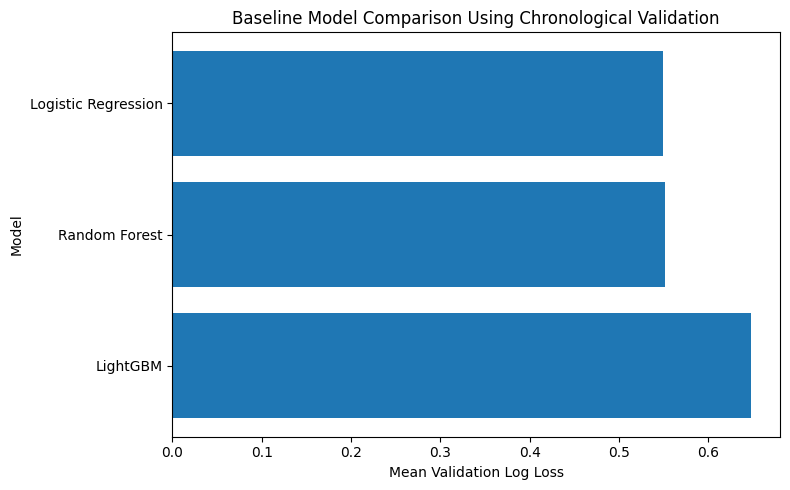

In [ ]:
plot_data = (
    baseline_summary
    .sort_values(
        "mean_log_loss",
        ascending=False
    )
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    plot_data.index,
    plot_data["mean_log_loss"]
)

plt.xlabel(
    "Mean Validation Log Loss"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Baseline Model Comparison "
    "Using Chronological Validation"
)

plt.tight_layout()
plt.show()

## 79. Compare Brier Score

Brier Score measures the mean squared difference between predicted probabilities and actual binary outcomes.

A lower Brier Score indicates better probability predictions.

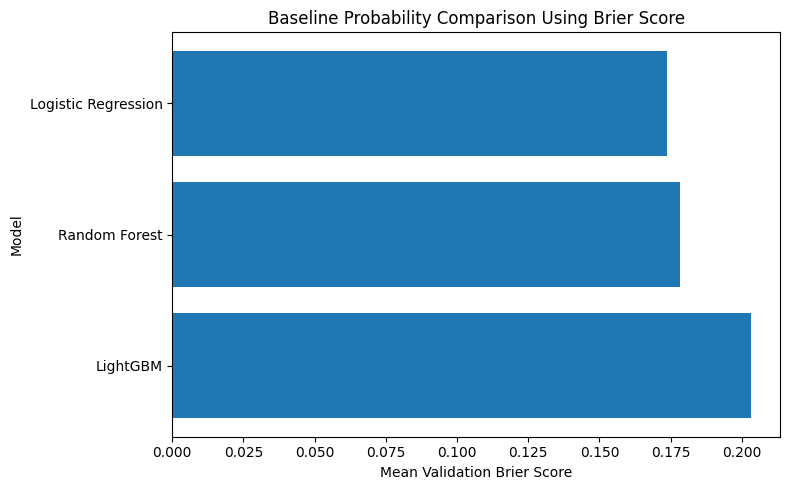

In [ ]:
plot_data = (
    baseline_summary
    .sort_values(
        "mean_brier",
        ascending=False
    )
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    plot_data.index,
    plot_data["mean_brier"]
)

plt.xlabel(
    "Mean Validation Brier Score"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Baseline Probability Comparison "
    "Using Brier Score"
)

plt.tight_layout()
plt.show()

## 80. Compare ROC-AUC

ROC-AUC evaluates how well the model ranks winning chase states above losing chase states across different classification thresholds.

Unlike Log Loss and Brier Score, a higher ROC-AUC is better.

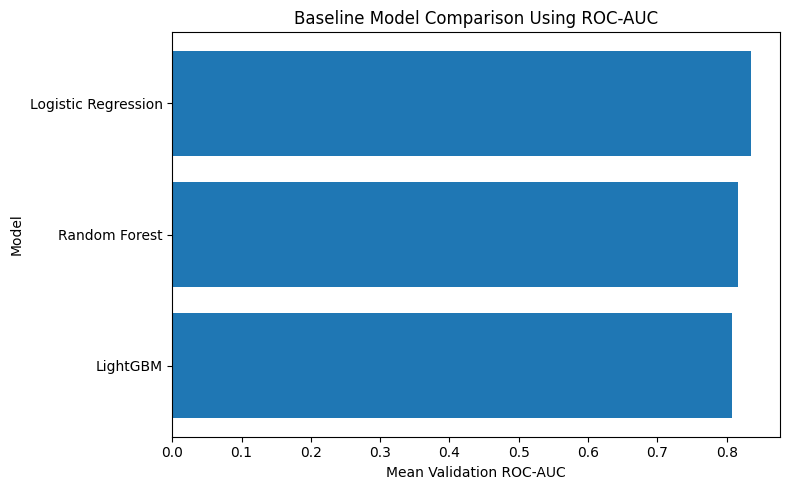

In [ ]:
plot_data = (
    baseline_summary
    .sort_values(
        "mean_roc_auc"
    )
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    plot_data.index,
    plot_data["mean_roc_auc"]
)

plt.xlabel(
    "Mean Validation ROC-AUC"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Baseline Model Comparison "
    "Using ROC-AUC"
)

plt.tight_layout()
plt.show()

## 81. Compare Classification Accuracy

Accuracy is also reported because it provides an intuitive measure of how frequently the predicted winning side is correct when a probability threshold of 0.5 is used.

However, accuracy is a secondary metric for this project because two probabilities such as 0.51 and 0.95 produce the same binary prediction despite representing very different levels of confidence.

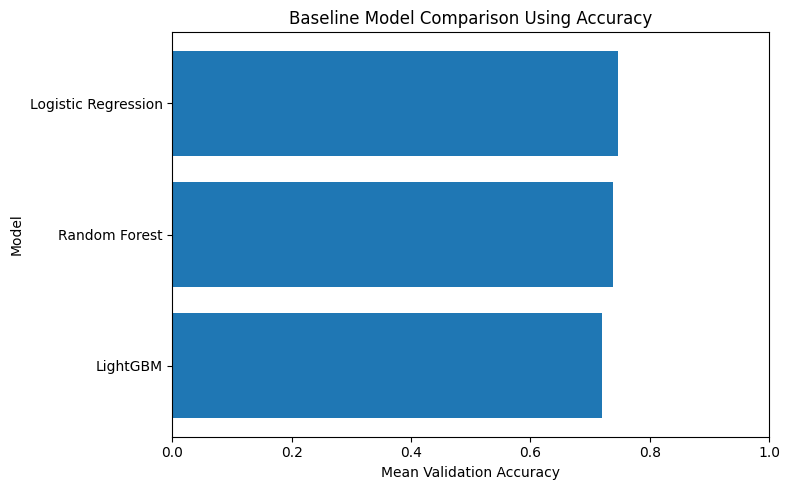

In [ ]:
plot_data = (
    baseline_summary
    .sort_values(
        "mean_accuracy"
    )
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    plot_data.index,
    plot_data["mean_accuracy"]
)

plt.xlabel(
    "Mean Validation Accuracy"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Baseline Model Comparison "
    "Using Accuracy"
)

plt.xlim(
    0,
    1
)

plt.tight_layout()
plt.show()

## 82. Identify the Best Baseline by Log Loss

The baseline models are ranked using mean validation Log Loss.

This ranking is only a baseline comparison.

The model ranked first at this stage is not automatically the final model because each candidate will still undergo controlled hyperparameter tuning.

In [ ]:
baseline_ranking = (
    baseline_summary[
        [
            "mean_log_loss",
            "mean_brier",
            "mean_roc_auc",
            "mean_accuracy"
        ]
    ]
    .sort_values(
        "mean_log_loss"
    )
)

display(
    baseline_ranking
)

print(
    "\nBest untuned baseline "
    "by mean Log Loss:"
)

print(
    baseline_ranking.index[0]
)

,mean_log_loss,mean_brier,mean_roc_auc,mean_accuracy
Model,,,,
Logistic Regression,0.549350,0.173815,0.835218,0.746893
Random Forest,0.551568,0.178301,0.816307,0.738516
LightGBM,0.647685,0.203225,0.807215,0.719913



Best untuned baseline by mean Log Loss:
Logistic Regression


## Baseline Modelling Summary

Three machine-learning algorithms have now been evaluated:

- Logistic Regression
- Random Forest
- LightGBM

Every model used:

- The same predictive features
- The same chronological validation seasons
- The same training and validation observations
- Training-only preprocessing
- The same evaluation metrics

The 2020 season has not been used during this process.

The current results represent untuned baselines rather than final models.

The next stage will perform controlled hyperparameter tuning for each model using the same expanding-window validation strategy.

# Hyperparameter Tuning

The candidate models are now tuned using the same four season-based expanding-window cross-validation folds used during baseline evaluation.

Hyperparameter tuning is performed only on the 2008–2019 development data.

The untouched 2020 season is not used during hyperparameter selection.

Since the project predicts win probabilities, mean validation Log Loss is used as the primary tuning metric.

In [ ]:
from sklearn.model_selection import GridSearchCV

## 83. Define a Common Hyperparameter Tuning Function

GridSearchCV evaluates every specified hyperparameter combination using the existing chronological cross-validation folds.

Scikit-learn maximizes its scoring metric. Therefore, `neg_log_loss` is used internally.

A larger negative-Log-Loss score corresponds to a smaller actual Log Loss.

The entire pipeline is passed to GridSearchCV so that preprocessing is fitted separately on the training portion of every fold.

In [ ]:
def tune_model(
    pipeline,
    param_grid,
    model_name
):

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="neg_log_loss",
        cv=custom_cv_splits,
        n_jobs=-1,
        refit=True,
        verbose=1,
        return_train_score=False
    )

    search.fit(
        X_dev,
        y_dev
    )

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print("\nBest parameters:")
    print(search.best_params_)

    print(
        "\nBest mean CV Log Loss:",
        round(-search.best_score_, 6)
    )

    return search

## 84. Tune Logistic Regression

Two hyperparameters are tuned:

### Regularization Strength (`C`)

Six values are considered over several orders of magnitude:

- 0.001
- 0.01
- 0.1
- 1
- 10
- 100

Smaller values of `C` correspond to stronger regularization, while larger values correspond to weaker regularization.

### Regularization Type (`penalty`)

Two regularization methods are compared:

- L1 regularization
- L2 regularization

The `liblinear` solver is used because it supports both L1 and L2 regularization for binary Logistic Regression.

In [ ]:
logistic_tuning_pipeline = clone(
    logistic_baseline
)

logistic_tuning_pipeline.set_params(
    model__solver="liblinear",
    model__max_iter=2000
)

logistic_param_grid = {
    "model__C": np.logspace(
        -3,
        2,
        6
    ),

    "model__penalty": [
        "l1",
        "l2"
    ]
}

print(
    "C values being tested:"
)

print(
    logistic_param_grid[
        "model__C"
    ]
)

print(
    "\nPenalties being tested:"
)

print(
    logistic_param_grid[
        "model__penalty"
    ]
)

C values being tested:
[1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]

Penalties being tested:
['l1', 'l2']


In [ ]:
logistic_search = tune_model(
    pipeline=
        logistic_tuning_pipeline,

    param_grid=
        logistic_param_grid,

    model_name=
        "Logistic Regression"
)

Fitting 4 folds for each of 12 candidates, totalling 48 fits

Logistic Regression

Best parameters:
{'model__C': np.float64(0.01), 'model__penalty': 'l1'}

Best mean CV Log Loss: 0.482669


## 85. Inspect All Logistic Regression Tuning Results

The complete tuning table is inspected rather than looking only at the winning configuration.

This helps determine:

- Which regularization type performs better
- How performance changes as `C` changes
- Whether the best `C` lies at the edge of the search range

If the best value occurs at an extreme boundary such as 0.001 or 100, the search range may need to be expanded.

In [ ]:
logistic_cv_results = pd.DataFrame(
    logistic_search.cv_results_
)

logistic_tuning_table = (
    logistic_cv_results[
        [
            "param_model__C",
            "param_model__penalty",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
    .copy()
)

logistic_tuning_table[
    "mean_log_loss"
] = (
    -logistic_tuning_table[
        "mean_test_score"
    ]
)

logistic_tuning_table[
    "std_log_loss"
] = (
    logistic_tuning_table[
        "std_test_score"
    ]
)

logistic_tuning_table = (
    logistic_tuning_table
    .sort_values(
        "mean_log_loss"
    )
    .reset_index(drop=True)
)

display(
    logistic_tuning_table[
        [
            "param_model__C",
            "param_model__penalty",
            "mean_log_loss",
            "std_log_loss",
            "rank_test_score"
        ]
    ]
)

,param_model__C,param_model__penalty,mean_log_loss,std_log_loss,rank_test_score
0,0.010,l1,0.482669,0.051627,1
1,0.010,l2,0.491848,0.040856,2
2,0.001,l2,0.497281,0.032712,3
3,0.001,l1,0.497360,0.032172,4
4,0.100,l2,0.514982,0.077114,5
5,0.100,l1,0.526228,0.108881,6
6,1.000,l2,0.552442,0.135594,7
7,1.000,l1,0.581633,0.187644,8
8,10.000,l2,0.595884,0.200038,9
9,100.000,l2,0.634373,0.255011,10


In [ ]:
best_logistic_C = (
    logistic_search
    .best_params_[
        "model__C"
    ]
)

best_logistic_penalty = (
    logistic_search
    .best_params_[
        "model__penalty"
    ]
)

print(
    "Best C:",
    best_logistic_C
)

print(
    "Best penalty:",
    best_logistic_penalty
)

print(
    "Best CV Log Loss:",
    -logistic_search.best_score_
)

Best C: 0.01
Best penalty: l1
Best CV Log Loss: 0.4826688783541334


### Boundary Check for `C`

If the best value of `C` is equal to the smallest or largest value in the search grid, the search range should be expanded.

If the optimum lies inside the search range, the current grid has successfully covered both stronger and weaker regularization regions.

In [ ]:
c_values = (
    logistic_param_grid[
        "model__C"
    ]
)

if best_logistic_C == min(c_values):

    print(
        "Best C is at the LOWER boundary."
    )

    print(
        "Consider testing smaller C values."
    )

elif best_logistic_C == max(c_values):

    print(
        "Best C is at the UPPER boundary."
    )

    print(
        "Consider testing larger C values."
    )

else:

    print(
        "Best C lies inside the "
        "search range."
    )

Best C lies inside the search range.


## 86. Tune Random Forest

Random Forest has many possible hyperparameters. Rather than tuning every parameter, the search focuses on parameters that strongly control model complexity.

The following are tuned:

- `n_estimators`: Number of trees in the forest
- `max_depth`: Maximum depth of individual trees
- `min_samples_leaf`: Minimum observations required in a terminal leaf

The objective is to find a balance between model flexibility and generalization.

In [ ]:
rf_param_grid = {
    "model__n_estimators": [
        200,
        400
    ],

    "model__max_depth": [
        8,
        12,
        16,
        None
    ],

    "model__min_samples_leaf": [
        1,
        5
    ]
}

In [ ]:
rf_tuning_pipeline = clone(
    random_forest_baseline
)

rf_tuning_pipeline.set_params(
    model__n_jobs=1
)

rf_search = tune_model(
    pipeline=rf_tuning_pipeline,
    param_grid=rf_param_grid,
    model_name="Random Forest"
)

Fitting 4 folds for each of 16 candidates, totalling 64 fits

Random Forest

Best parameters:
{'model__max_depth': 16, 'model__min_samples_leaf': 5, 'model__n_estimators': 400}

Best mean CV Log Loss: 0.489994


In [ ]:
rf_cv_results = pd.DataFrame(
    rf_search.cv_results_
)

rf_tuning_table = (
    rf_cv_results[
        [
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__min_samples_leaf",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
    .copy()
)

rf_tuning_table["mean_log_loss"] = (
    -rf_tuning_table["mean_test_score"]
)

rf_tuning_table["std_log_loss"] = (
    rf_tuning_table["std_test_score"]
)

rf_tuning_table = (
    rf_tuning_table
    .sort_values("mean_log_loss")
    .reset_index(drop=True)
)

display(
    rf_tuning_table[
        [
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__min_samples_leaf",
            "mean_log_loss",
            "std_log_loss",
            "rank_test_score"
        ]
    ]
)

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,mean_log_loss,std_log_loss,rank_test_score
0,400,16,5,0.489994,0.050513,1
1,200,16,5,0.489996,0.050254,2
2,200,12,5,0.491142,0.050524,3
3,400,12,1,0.491595,0.049613,4
4,400,12,5,0.491650,0.050202,5
5,200,12,1,0.491842,0.050724,6
6,200,16,1,0.493152,0.052725,7
7,400,16,1,0.493351,0.054125,8
8,400,None,5,0.510252,0.051775,9
9,200,None,5,0.510586,0.049761,10


In [ ]:
print(
    "Best Random Forest parameters:"
)

print(
    rf_search.best_params_
)

print(
    "\nBest mean CV Log Loss:",
    -rf_search.best_score_
)

Best Random Forest parameters:
{'model__max_depth': 16, 'model__min_samples_leaf': 5, 'model__n_estimators': 400}

Best mean CV Log Loss: 0.4899936976551564


## LightGBM Hyperparameter Tuning

LightGBM is tuned using the same chronological cross-validation folds and Log Loss metric.

The search focuses on three influential hyperparameters:

- `n_estimators`: number of boosting trees
- `learning_rate`: contribution of each tree
- `num_leaves`: complexity of individual trees

A compact parameter space is used to balance model exploration and computation time.

In [ ]:
lgbm_tuning_pipeline = clone(
    lightgbm_baseline
)

# GridSearchCV handles parallel execution,
# so the LightGBM model itself uses one thread.
lgbm_tuning_pipeline.set_params(
    model__n_jobs=1
)

lgbm_param_grid = {
    "model__n_estimators": [
        200,
        400
    ],

    "model__learning_rate": [
        0.03,
        0.07
    ],

    "model__num_leaves": [
        15,
        31
    ]
}

print(
    "Number of LightGBM configurations:",
    2 * 2 * 2
)

print(
    "Total CV fits:",
    2 * 2 * 2 * 4
)

Number of LightGBM configurations: 8
Total CV fits: 32


In [ ]:
lgbm_search = tune_model(
    pipeline=lgbm_tuning_pipeline,
    param_grid=lgbm_param_grid,
    model_name="LightGBM"
)

Fitting 4 folds for each of 8 candidates, totalling 32 fits

LightGBM

Best parameters:
{'model__learning_rate': 0.03, 'model__n_estimators': 200, 'model__num_leaves': 15}

Best mean CV Log Loss: 0.489382


## 92. Inspect LightGBM Tuning Results

All tested LightGBM configurations are ranked according to their mean validation Log Loss.

Lower Log Loss indicates better probability predictions.

In [ ]:
lgbm_cv_results = pd.DataFrame(
    lgbm_search.cv_results_
)

lgbm_tuning_table = (
    lgbm_cv_results[
        [
            "param_model__n_estimators",
            "param_model__learning_rate",
            "param_model__num_leaves",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
    .copy()
)

lgbm_tuning_table["mean_log_loss"] = (
    -lgbm_tuning_table["mean_test_score"]
)

lgbm_tuning_table["std_log_loss"] = (
    lgbm_tuning_table["std_test_score"]
)

lgbm_tuning_table = (
    lgbm_tuning_table
    .sort_values("mean_log_loss")
    .reset_index(drop=True)
)

display(
    lgbm_tuning_table[
        [
            "param_model__n_estimators",
            "param_model__learning_rate",
            "param_model__num_leaves",
            "mean_log_loss",
            "std_log_loss",
            "rank_test_score"
        ]
    ]
)

,param_model__n_estimators,param_model__learning_rate,param_model__num_leaves,mean_log_loss,std_log_loss,rank_test_score
0,200,0.03,15,0.489382,0.078200,1
1,200,0.03,31,0.532567,0.096634,2
2,400,0.03,15,0.555806,0.149926,3
3,200,0.07,15,0.580241,0.158940,4
4,400,0.03,31,0.693872,0.155298,5
5,400,0.07,15,0.761907,0.260635,6
6,200,0.07,31,0.763936,0.219064,7
7,400,0.07,31,1.159742,0.329867,8


In [ ]:
print(
    "Best LightGBM parameters:"
)

print(
    lgbm_search.best_params_
)

print(
    "\nBest mean CV Log Loss:"
)

print(
    -lgbm_search.best_score_
)

Best LightGBM parameters:
{'model__learning_rate': 0.03, 'model__n_estimators': 200, 'model__num_leaves': 15}

Best mean CV Log Loss:
0.4893817366970041


## 93. Compare Best Hyperparameter-Tuned Models

After Logistic Regression, Random Forest and LightGBM have all completed tuning, their best chronological cross-validation results are summarized.

This table is used to compare the best configuration from each model family.

Final model selection has not yet been performed.

In [ ]:
tuning_summary = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest",
            "LightGBM"
        ],

        "Best CV Log Loss": [
            -logistic_search.best_score_,
            -rf_search.best_score_,
            -lgbm_search.best_score_
        ],

        "Best Parameters": [
            logistic_search.best_params_,
            rf_search.best_params_,
            lgbm_search.best_params_
        ]
    }
)

tuning_summary = (
    tuning_summary
    .sort_values(
        "Best CV Log Loss"
    )
    .reset_index(drop=True)
)

display(
    tuning_summary
)

,Model,Best CV Log Loss,Best Parameters
0,Logistic Regression,0.482669,"{'model__C': 0.01, 'model__penalty': 'l1'}"
1,LightGBM,0.489382,"{'model__learning_rate': 0.03, 'model__n_estim..."
2,Random Forest,0.489994,"{'model__max_depth': 16, 'model__min_samples_l..."


### Interpretation

The model with the lowest mean chronological cross-validation Log Loss has the strongest probability performance among the tuned candidates.

However, before declaring the final model, its fold-wise performance should also be checked to ensure that the result is reasonably stable across the 2016, 2017, 2018 and 2019 validation seasons.

In [ ]:
tuned_logistic = (
    logistic_search.best_estimator_
)

tuned_rf = (
    rf_search.best_estimator_
)

tuned_lgbm = (
    lgbm_search.best_estimator_
)

In [ ]:
tuned_logistic_results, logistic_tuned_oof = (
    evaluate_model_cv(
        pipeline=tuned_logistic,
        X=X_dev,
        y=y_dev,
        cv_splits=custom_cv_splits,
        development_df=development_data,
        model_name="Logistic Regression"
    )
)

tuned_rf_results, rf_tuned_oof = (
    evaluate_model_cv(
        pipeline=tuned_rf,
        X=X_dev,
        y=y_dev,
        cv_splits=custom_cv_splits,
        development_df=development_data,
        model_name="Random Forest"
    )
)

tuned_lgbm_results, lgbm_tuned_oof = (
    evaluate_model_cv(
        pipeline=tuned_lgbm,
        X=X_dev,
        y=y_dev,
        cv_splits=custom_cv_splits,
        development_df=development_data,
        model_name="LightGBM"
    )
)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
tuned_fold_results = pd.concat(
    [
        tuned_logistic_results,
        tuned_rf_results,
        tuned_lgbm_results
    ],
    ignore_index=True
)

display(
    tuned_fold_results[
        [
            "Model",
            "Validation Year",
            "Log Loss",
            "Brier Score",
            "ROC-AUC",
            "Accuracy"
        ]
    ]
)

,Model,Validation Year,Log Loss,Brier Score,ROC-AUC,Accuracy
0,Logistic Regression,2016,0.412764,0.136162,0.879766,0.792305
1,Logistic Regression,2017,0.550155,0.192434,0.800722,0.696855
2,Logistic Regression,2018,0.508548,0.173411,0.817855,0.736834
3,Logistic Regression,2019,0.459208,0.157893,0.851149,0.746390
4,Random Forest,2016,0.429618,0.142123,0.878736,0.788552
5,Random Forest,2017,0.546027,0.188801,0.798700,0.695440
6,Random Forest,2018,0.533469,0.180709,0.797382,0.720780
7,Random Forest,2019,0.450862,0.150625,0.857640,0.777226
8,LightGBM,2016,0.405004,0.133716,0.888243,0.799187
9,LightGBM,2017,0.610506,0.206064,0.781668,0.689308


## 94. Summarize Tuned Cross-Validation Performance

The mean and standard deviation across validation seasons are calculated.

Mean performance measures overall predictive quality, while standard deviation provides an indication of how stable the model is across different IPL seasons.

In [ ]:
tuned_summary_full = (
    tuned_fold_results
    .groupby("Model")
    .agg(
        mean_log_loss=(
            "Log Loss",
            "mean"
        ),

        std_log_loss=(
            "Log Loss",
            "std"
        ),

        mean_brier=(
            "Brier Score",
            "mean"
        ),

        std_brier=(
            "Brier Score",
            "std"
        ),

        mean_roc_auc=(
            "ROC-AUC",
            "mean"
        ),

        std_roc_auc=(
            "ROC-AUC",
            "std"
        ),

        mean_accuracy=(
            "Accuracy",
            "mean"
        ),

        std_accuracy=(
            "Accuracy",
            "std"
        )
    )
    .sort_values(
        "mean_log_loss"
    )
)

display(
    tuned_summary_full
)

,mean_log_loss,std_log_loss,mean_brier,std_brier,mean_roc_auc,std_roc_auc,mean_accuracy,std_accuracy
Model,,,,,,,,
Logistic Regression,0.482669,0.059613,0.164975,0.023844,0.837373,0.035172,0.743096,0.039200
LightGBM,0.489382,0.090297,0.165267,0.030989,0.836619,0.046404,0.746875,0.045383
Random Forest,0.489994,0.058328,0.165565,0.022672,0.833114,0.041409,0.745500,0.044636


# Final Model Training and Evaluation

Logistic Regression achieved the best overall probability performance during chronological cross-validation and is therefore selected as the final model.

The selected hyperparameter configuration is retrained using all available development data from 2008–2019.

The completely untouched 2020 season is then used for final evaluation.

In [ ]:
from sklearn.base import clone

final_model = clone(
    logistic_search.best_estimator_
)

final_model.fit(
    X_dev,
    y_dev
)

print(
    "Final Logistic Regression model "
    "trained on 2008–2019 data."
)

print(
    "\nSelected hyperparameters:"
)

print(
    logistic_search.best_params_
)

Final Logistic Regression model trained on 2008–2019 data.

Selected hyperparameters:
{'model__C': np.float64(0.01), 'model__penalty': 'l1'}


## Final Prediction on the 2020 Season

The trained model now predicts the probability that the chasing team wins for every live match state in the 2020 test season.

A probability threshold of 0.5 is used only when converting probabilities into binary win/loss predictions.

In [ ]:
test_probability = (
    final_model
    .predict_proba(
        X_test
    )[:, 1]
)

test_prediction = (
    test_probability >= 0.5
).astype(int)

print(
    "Number of 2020 predictions:",
    len(test_probability)
)

Number of 2020 predictions: 6492


## Final Prediction on the 2020 Season

The trained model now predicts the probability that the chasing team wins for every live match state in the 2020 test season.

A probability threshold of 0.5 is used only when converting probabilities into binary win/loss predictions.

In [ ]:
test_probability = (
    final_model
    .predict_proba(
        X_test
    )[:, 1]
)

test_prediction = (
    test_probability >= 0.5
).astype(int)

print(
    "Number of 2020 predictions:",
    len(test_probability)
)

Number of 2020 predictions: 6492


## Final Test Metrics

Since the project predicts win probabilities, Log Loss and Brier Score are particularly important.

ROC-AUC measures ranking ability, while Accuracy, Precision, Recall and F1 Score evaluate the corresponding binary predictions at a threshold of 0.5.

In [ ]:
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

final_test_metrics = pd.DataFrame(
    {
        "Metric": [
            "Log Loss",
            "Brier Score",
            "ROC-AUC",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score"
        ],

        "Value": [
            log_loss(
                y_test,
                test_probability
            ),

            brier_score_loss(
                y_test,
                test_probability
            ),

            roc_auc_score(
                y_test,
                test_probability
            ),

            accuracy_score(
                y_test,
                test_prediction
            ),

            precision_score(
                y_test,
                test_prediction
            ),

            recall_score(
                y_test,
                test_prediction
            ),

            f1_score(
                y_test,
                test_prediction
            )
        ]
    }
)

display(
    final_test_metrics
)

,Metric,Value
0,Log Loss,0.412787
1,Brier Score,0.134233
2,ROC-AUC,0.890813
3,Accuracy,0.810074
4,Precision,0.798022
5,Recall,0.826505
6,F1 Score,0.812014


## Probability Calibration Analysis

A well-calibrated probability model should produce probabilities that correspond reasonably well to observed outcomes.

For example, among match states receiving approximately 70% predicted win probability, roughly 70% should ideally result in a chasing-team win.

The predictions are grouped into probability ranges and compared with the observed win rate.

In [ ]:
calibration_data = pd.DataFrame(
    {
        "predicted_probability":
            test_probability,

        "actual_result":
            y_test.to_numpy()
    }
)

calibration_data[
    "probability_bin"
] = pd.cut(
    calibration_data[
        "predicted_probability"
    ],

    bins=np.linspace(
        0,
        1,
        11
    ),

    include_lowest=True
)

calibration_table = (
    calibration_data
    .groupby(
        "probability_bin",
        observed=False
    )
    .agg(
        number_of_states=(
            "actual_result",
            "size"
        ),

        mean_predicted_probability=(
            "predicted_probability",
            "mean"
        ),

        actual_win_rate=(
            "actual_result",
            "mean"
        )
    )
    .dropna()
)

display(
    calibration_table
)

,number_of_states,mean_predicted_probability,actual_win_rate
probability_bin,,,
"(-0.001, 0.1]",1452,0.031603,0.006198
"(0.1, 0.2]",550,0.145002,0.189091
"(0.2, 0.3]",415,0.247334,0.228916
"(0.3, 0.4]",369,0.350859,0.441734
"(0.4, 0.5]",369,0.441063,0.509485
"(0.5, 0.6]",266,0.554054,0.676692
"(0.6, 0.7]",356,0.649160,0.609551
"(0.7, 0.8]",570,0.751078,0.759649
"(0.8, 0.9]",708,0.854567,0.765537


# Logistic Regression Feature Interpretation

The Logistic Regression model assigns a coefficient to every transformed feature.

Positive coefficients increase the log-odds of a chasing-team win, while negative coefficients decrease the log-odds.

Because numerical variables were standardized, their coefficient magnitudes can be compared more meaningfully.

Categorical variables appear as one-hot encoded team and venue indicators.

In [ ]:
preprocessor = (
    final_model
    .named_steps[
        "preprocessor"
    ]
)

logistic_model = (
    final_model
    .named_steps[
        "model"
    ]
)

feature_names = (
    preprocessor
    .get_feature_names_out()
)

coefficients = (
    logistic_model.coef_[0]
)

coefficient_table = pd.DataFrame(
    {
        "Feature":
            feature_names,

        "Coefficient":
            coefficients,

        "Absolute Coefficient":
            np.abs(
                coefficients
            )
    }
)

coefficient_table = (
    coefficient_table
    .sort_values(
        "Absolute Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    coefficient_table.head(20)
)

,Feature,Coefficient,Absolute Coefficient
0,num__required_run_rate,-3.983567,3.983567
1,num__runs_required,-1.931916,1.931916
2,cat__bowling_team_Gujarat Lions,1.880917,1.880917
3,cat__batting_team_Pune Warriors,-1.632057,1.632057
4,num__wickets_remaining,1.117516,1.117516
5,cat__batting_team_Deccan Chargers,-1.048322,1.048322
6,cat__venue_MA Chidambaram Stadium,-1.044111,1.044111
7,cat__batting_team_Chennai Super Kings,0.945904,0.945904
8,cat__venue_Holkar Cricket Stadium,0.920298,0.920298
9,cat__venue_Kingsmead,-0.840805,0.840805


# Real-Time IPL Win Probability Function

The trained pipeline can now be used to estimate win probability from a live second-innings match state.

The function accepts the current score information and automatically calculates:

- Runs required
- Balls remaining
- Wickets remaining
- Current run rate
- Required run rate

These engineered features are passed to the fitted Logistic Regression pipeline.

In [ ]:
def predict_win_probability(
    batting_team,
    bowling_team,
    venue,
    target_runs,
    current_score,
    legal_balls_bowled,
    wickets_lost,
    target_overs=20
):

    scheduled_balls = int(
        target_overs * 6
    )

    balls_remaining = max(
        scheduled_balls
        - legal_balls_bowled,
        0
    )

    runs_required = max(
        target_runs
        - current_score,
        0
    )

    wickets_remaining = max(
        10 - wickets_lost,
        0
    )

    if legal_balls_bowled <= 0:
        raise ValueError(
            "At least one legal ball "
            "must have been bowled."
        )

    current_run_rate = (
        current_score
        * 6
        / legal_balls_bowled
    )

    if balls_remaining > 0:

        required_run_rate = (
            runs_required
            * 6
            / balls_remaining
        )

    elif runs_required == 0:

        required_run_rate = 0.0

    else:

        required_run_rate = np.nan


    live_state = pd.DataFrame(
        {
            "batting_team": [
                batting_team
            ],

            "bowling_team": [
                bowling_team
            ],

            "venue": [
                venue
            ],

            "target_runs": [
                target_runs
            ],

            "runs_required": [
                runs_required
            ],

            "balls_remaining": [
                balls_remaining
            ],

            "wickets_remaining": [
                wickets_remaining
            ],

            "current_run_rate": [
                current_run_rate
            ],

            "required_run_rate": [
                required_run_rate
            ]
        }
    )


    chasing_probability = (
        final_model
        .predict_proba(
            live_state
        )[0, 1]
    )


    return {
        "Chasing Team Win Probability":
            round(
                chasing_probability * 100,
                2
            ),

        "Defending Team Win Probability":
            round(
                (
                    1
                    - chasing_probability
                )
                * 100,
                2
            )
    }

# Save the Final Model

The complete fitted pipeline, including preprocessing and Logistic Regression, is saved so that predictions can later be generated without retraining the model.

In [ ]:
import joblib

MODEL_PATH = (
    "/content/"
    "ipl_win_probability_model.joblib"
)

joblib.dump(
    final_model,
    MODEL_PATH
)

print(
    "Final model saved to:",
    MODEL_PATH
)

Final model saved to: /content/ipl_win_probability_model.joblib


**we don't input the features for prediction.We just input the values we know while seeing the score card,the model itself calculates the feature values for prediction and takes it as input.We don't need to specify the run rate and all**

In [ ]:
prediction = predict_win_probability(
    batting_team="Chennai Super Kings",
    bowling_team="Mumbai Indians",
    venue="Wankhede Stadium",
    target_runs=181,
    current_score=126,
    legal_balls_bowled=92,
    wickets_lost=4,
    target_overs=20
)

print(prediction)

{'Chasing Team Win Probability': np.float64(50.68), 'Defending Team Win Probability': np.float64(49.32)}
